In [1]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.preprocessing import minmax_scale
import scipy
import seaborn as sns

In [13]:
u = mda.Universe("Neutral-with-Ca.pdb")

protein_ca_selection = 'protein and segid PROA'

residue_indices = []
contact_fractions = []
cutoff = 10.0
distance = []
k = []
contact = {}
for residue in u.select_atoms(protein_ca_selection).residues:
    #residue_index = residue.resid
    residue_indices.append(residue.resid-7)
    #ca_atom = u.select_atoms(f"resid {residue.resid} and name CA")
    #ca_coords = ca_atom.positions[0]
    popc_selection = u.select_atoms(f"resname POPC and around {cutoff} resid {residue.resid}")
    popc_ids_within_cutoff = set(popc_selection.resids)
    k.append(len(popc_ids_within_cutoff))
    #normalized_value = len(popc_ids_within_cutoff) / len(u.select_atoms("resname POPC"))
    #contact[residue_index] = preprocessing.normalize(len(popc_ids_within_cutoff))
    #popc_ids_within_cutoff
    
contact_popc = preprocessing.normalize([np.array(k)])[0]    
    #popc_selection = f"around {cutoff} (resname POPC and not (name H* or name C*))"
    #popc_within_cutoff = u.select_atoms(popc_selection, around=ca_atom)

In [14]:
print(contact_popc)

[0.14977819 0.13401207 0.14189513 0.13401207 0.12612901 0.18131045
 0.16554432 0.12612901 0.18919351 0.19707657 0.12612901 0.16554432
 0.22860882 0.14189513 0.16554432 0.2128427  0.17342738 0.16554432
 0.26014107 0.24437495 0.17342738 0.15766126 0.2128427  0.15766126
 0.11036288 0.18919351 0.25225801 0.18919351 0.16554432 0.18131045
 0.22072576]


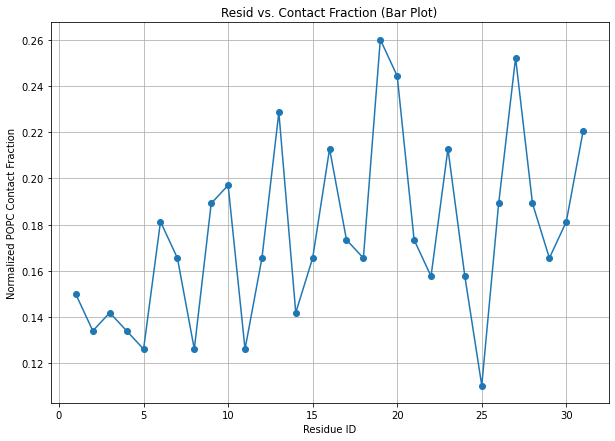

In [30]:
#resid_list = list(contact.keys())
#contact_fraction_list = list(contact.values())
plt.figure(figsize=[10,7])
plt.plot(residue_indices,contact_popc,"o-")
plt.xlabel('Residue ID')
plt.ylabel('Normalized POPC Contact Fraction')
plt.title('Resid vs. Contact Fraction (Bar Plot)')
plt.grid(True)
plt.show()

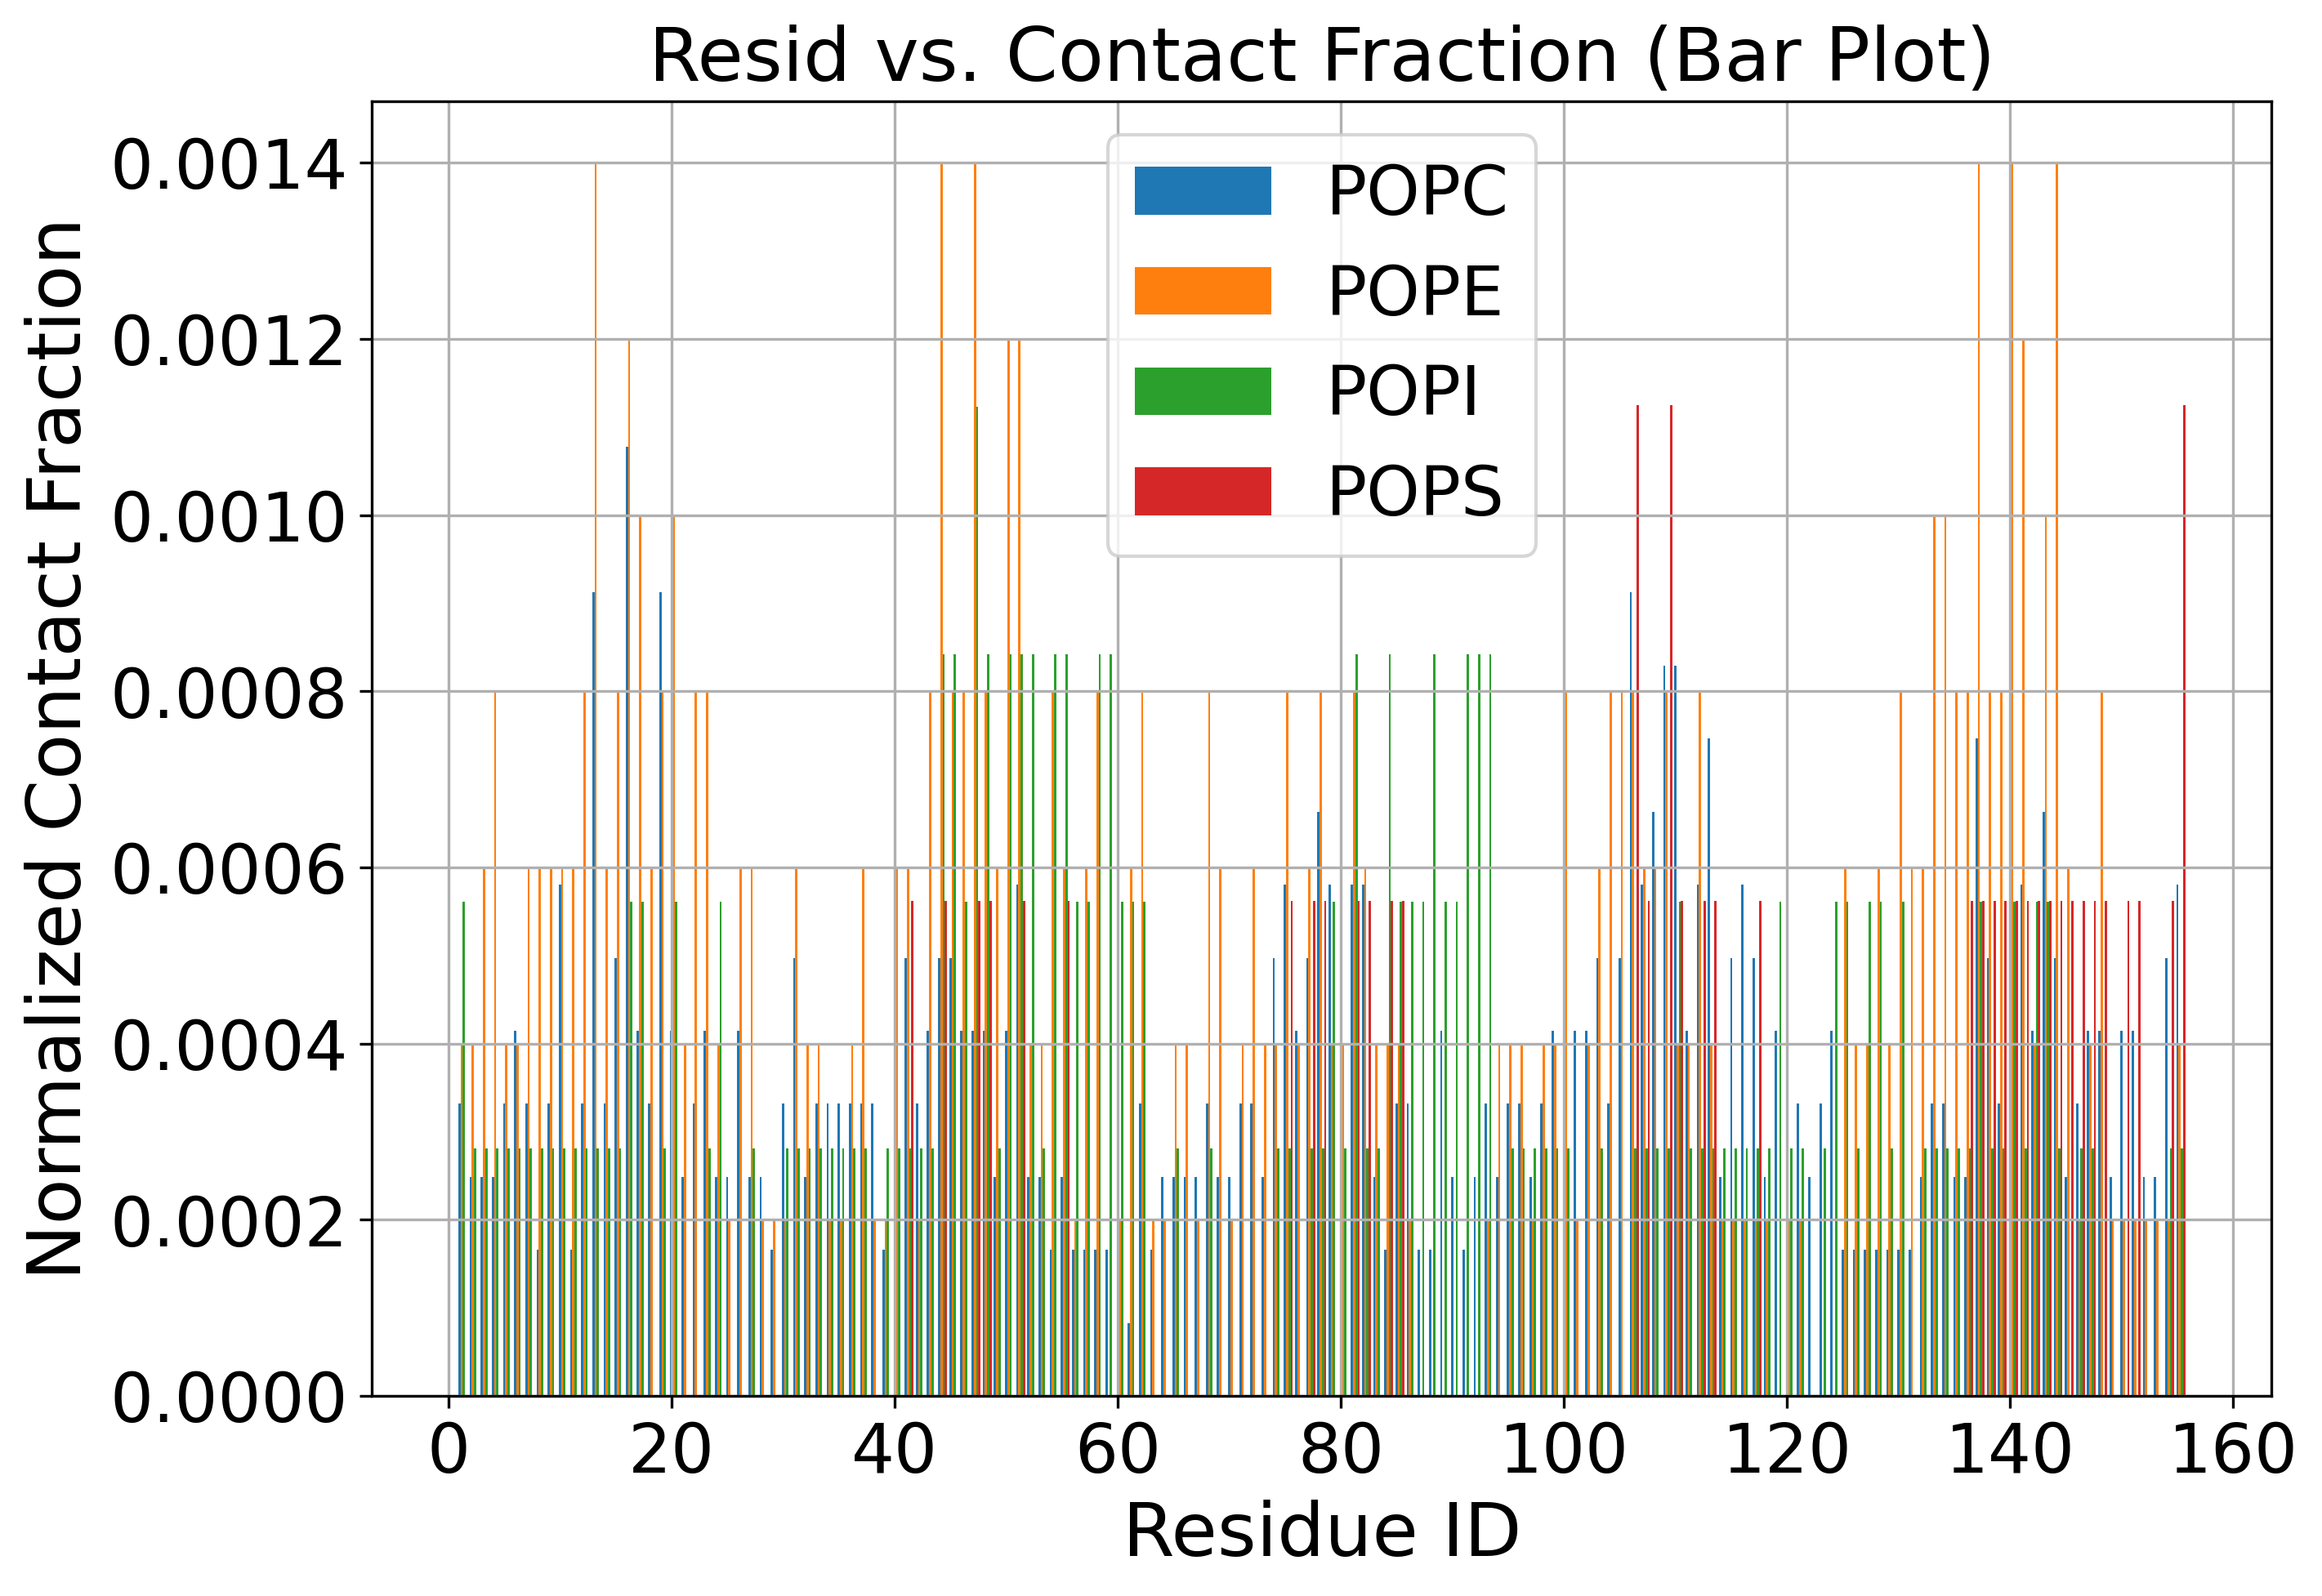

In [146]:
import MDAnalysis as mda
import matplotlib.pyplot as plt
from sklearn.preprocessing import minmax_scale

topology = 'Neutral-without-calcium.gro'
trajectory = 'Neutral-without-Calcium.xtc'
u = mda.Universe(topology, trajectory)

protein_ca_selection = 'protein and name CA'

residue_indices = []
contacts = {}
cutoff = 10.0

lipids = ['POPC','POPE', 'POPI', 'POPS']

for residue in u.select_atoms(protein_ca_selection).residues:
    residue_index = residue.resid
    residue_indices.append(residue_index)
    
    contact_values = []
    for lipid in lipids:
        lipid_selection = u.select_atoms(f"resname {lipid} and around {cutoff} resid {residue_index}")
        lipid_ids_within_cutoff = set(lipid_selection.resids.tolist())
        
        normalized_value = len(lipid_ids_within_cutoff) / len(u.select_atoms(f"resname {lipid}"))
        contact_values.append(normalized_value)
    
    contacts[residue_index] = contact_values

resid_list = list(contacts.keys())
contact_fraction_lists = list(contacts.values())

plt.figure(figsize=(10, 7),dpi=300)
for lipid_index, lipid in enumerate(lipids):
    plt.bar([resid + lipid_index*0.2 for resid in resid_list], [cf[lipid_index] for cf in contact_fraction_lists], width=0.2, label=lipid)

plt.xlabel('Residue ID',fontsize=22)
plt.ylabel('Normalized Contact Fraction',fontsize=22)
plt.title('Resid vs. Contact Fraction (Bar Plot)',fontsize=22)
plt.xticks(fontsize=20)
#[resid + 0.3 for resid in resid_list], resid_list)
plt.yticks(fontsize=20)
plt.legend(fontsize=20)
plt.grid(True)
plt.show()

In [122]:
u = mda.Universe("Neutral-without-calcium.gro","Neutral-without-Calcium.xtc")

protein_ca_selection = 'protein and name CA'

residue_indices = []
lipids = ['POPC', 'POPE', 'POPI', 'POPS']
cutoff = 10.0
distance = []
POPC = []
POPS = []
POPE = []
POPI = []

for residue in u.select_atoms(protein_ca_selection).residues:
    residue_indices.append(residue.resid)
    for lipid in lipids:
        lipid_selection = u.select_atoms(f"resname {lipid} and around {cutoff} resid {residue.resid}")
        lipid_ids_within_cutoff = set(lipid_selection.resids)
contact_popc = preprocessing.normalize([np.array(POPC)])[0]    

{}


In [ ]:
plt.figure(figsize=[10,7])
plt.bar(residue_indices,contact_popc)
plt.xlabel('Residue ID')
plt.ylabel('Normalized POPC Contact Fraction')
plt.title('Resid vs. Contact Fraction (Bar Plot)')
plt.grid(True)
plt.show()

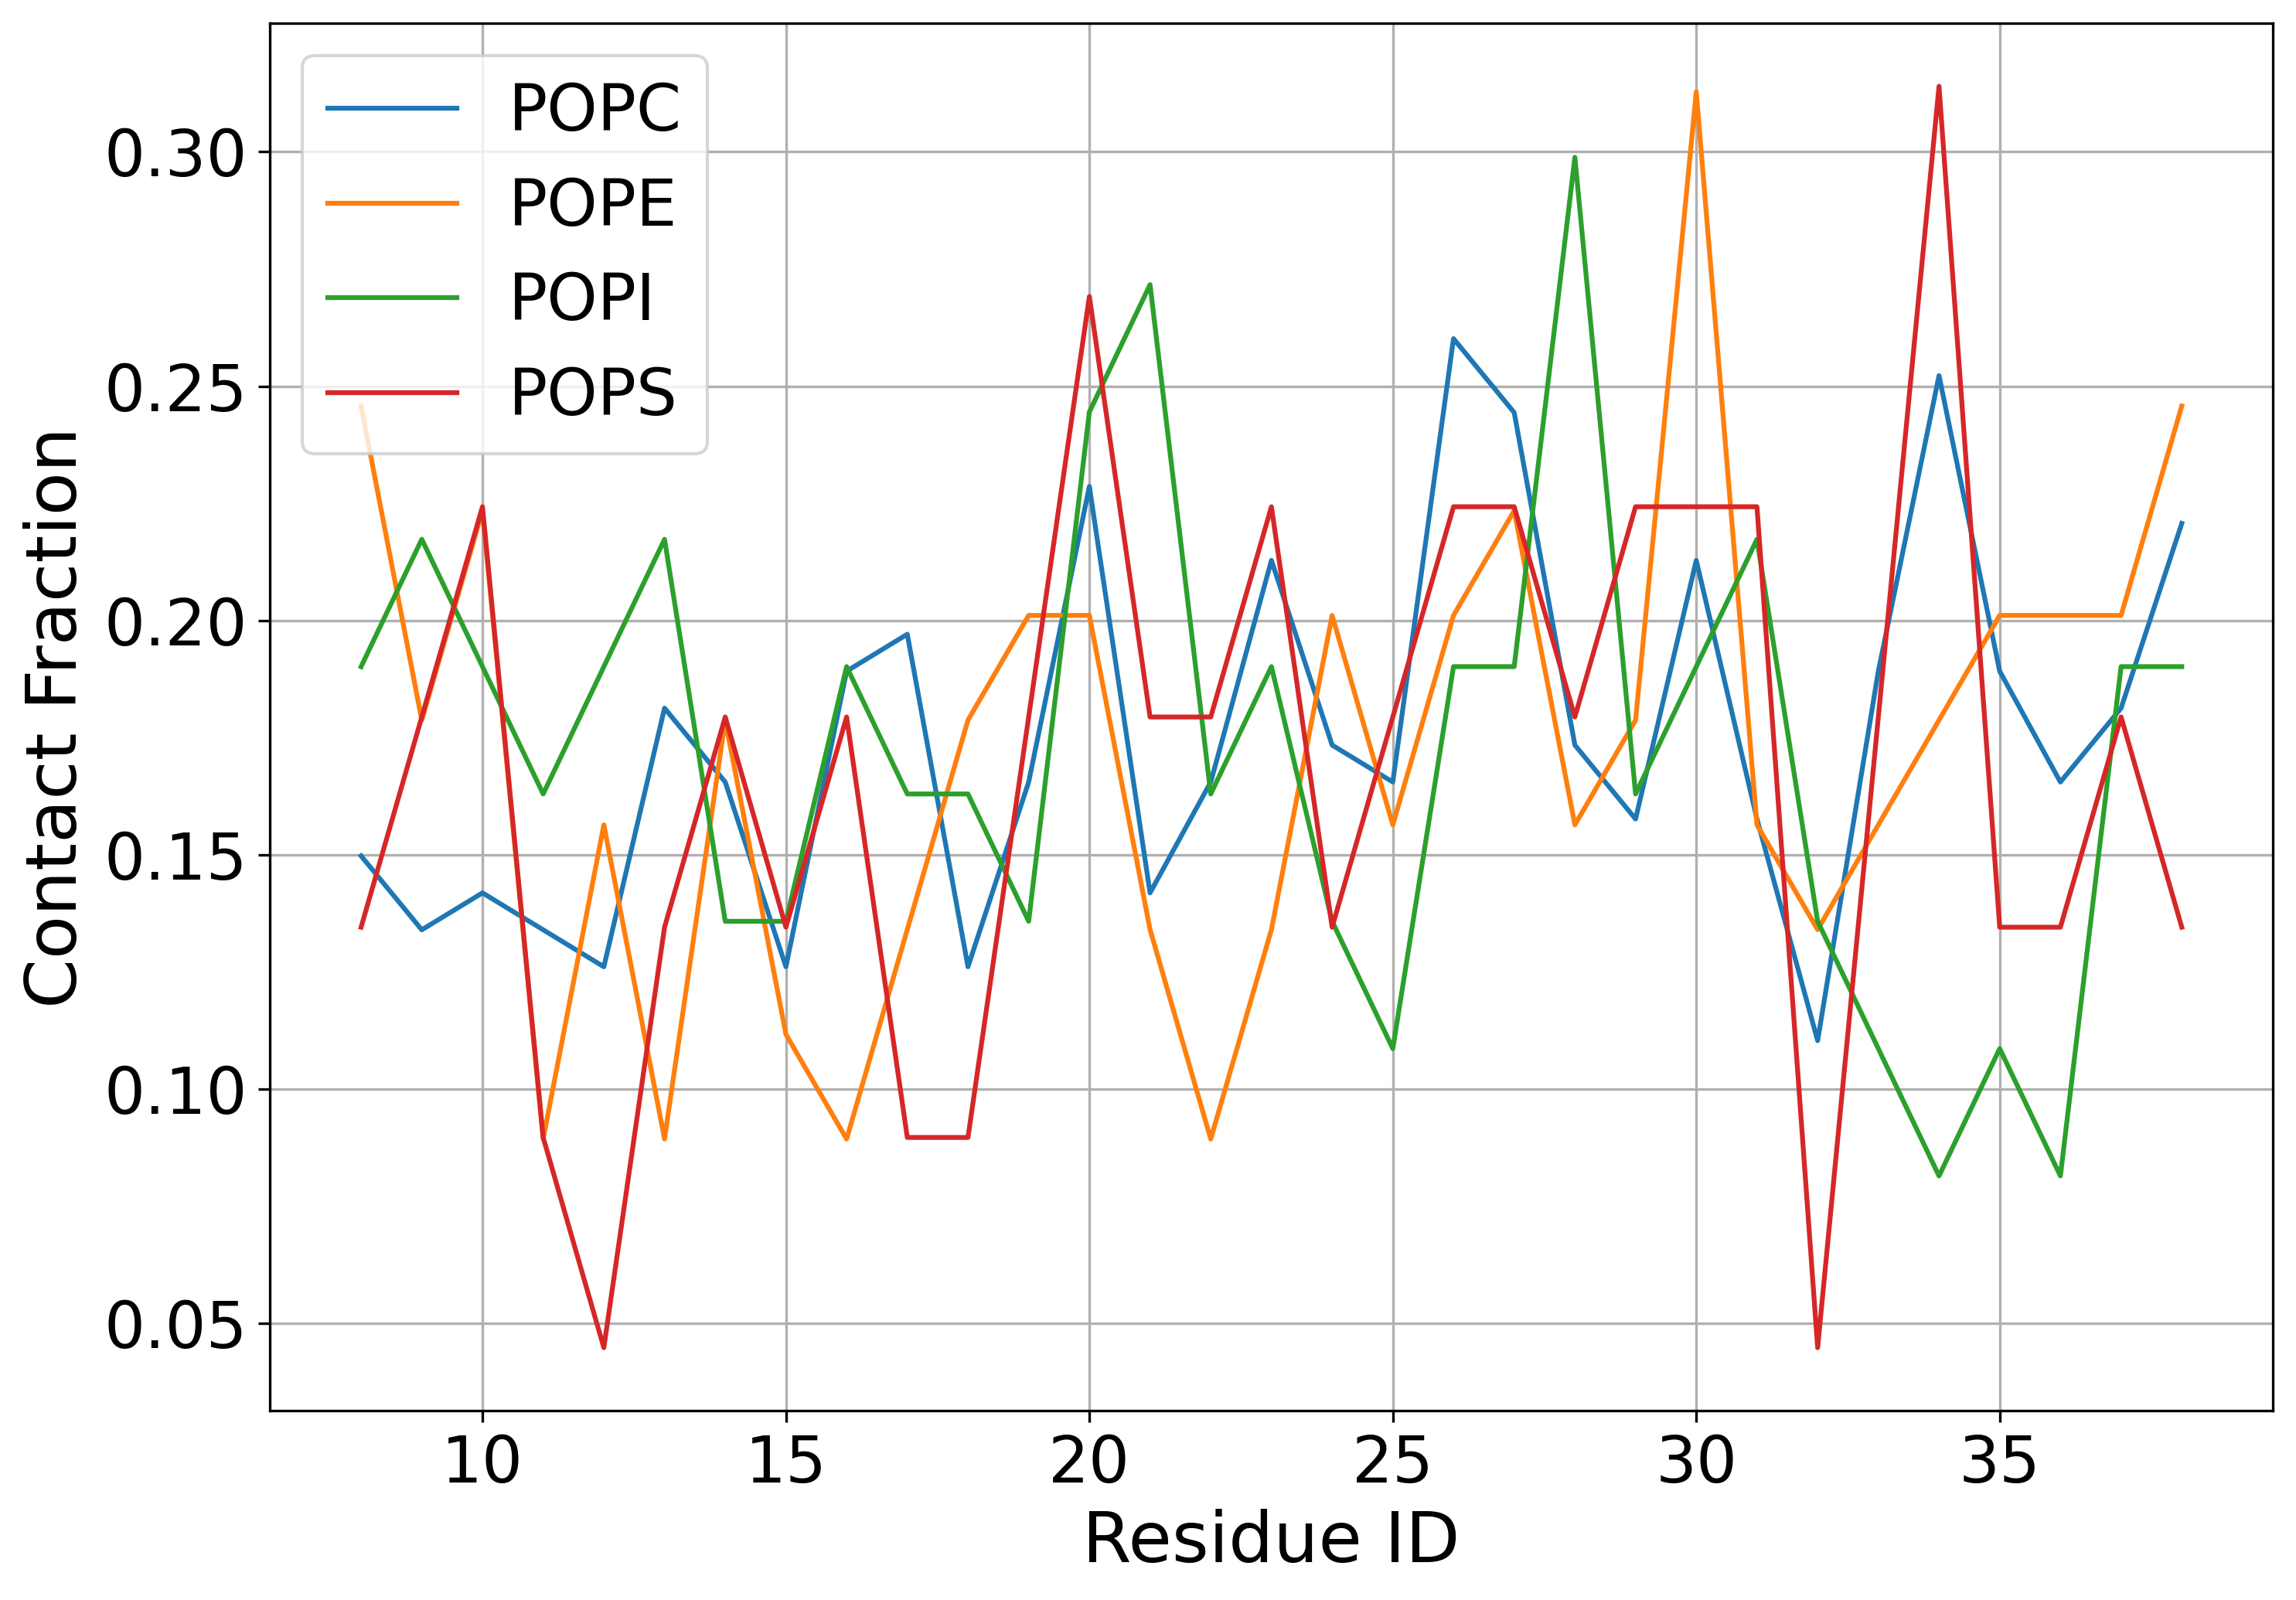

In [34]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing

topology = 'Neutral-with-Ca.pdb'
#trajectory = 'Neutral-without-Calcium.xtc'
u = mda.Universe(topology)

protein_ca_selection = 'protein and segid PROA'

residue_indices = []
lipids = ['POPC', 'POPE', 'POPI', 'POPS']
contact_fractions = {lipid: [] for lipid in lipids}
cutoff = 10.0

for residue in u.select_atoms(protein_ca_selection).residues:
    residue_indices.append(residue.resid)
    for lipid in lipids:
        lipid_selection = u.select_atoms(f"resname {lipid} and around {cutoff} resid {residue.resid}")
        lipid_ids_within_cutoff = set(lipid_selection.resids)
        contact_fraction = len(lipid_ids_within_cutoff) / len(u.select_atoms(f"resname {lipid}").residues)
        contact_fractions[lipid].append(contact_fraction)


plt.figure(figsize=[10,7],dpi=300)
for lipid, contact_fraction_list in contact_fractions.items():
    normalized_contact_fraction = preprocessing.normalize([np.array(contact_fraction_list)])[0]
    plt.plot(residue_indices, normalized_contact_fraction,alpha=1, label = lipid)

plt.xlabel('Residue ID',fontsize=22)
plt.ylabel('Contact Fraction',fontsize=22)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
#plt.title('Resid vs. Normalized Contact Fraction (Bar Plot)')
plt.legend(loc='upper left',fontsize=20)
plt.grid(True)
plt.tight_layout()
#plt.savefig('Neutral_without_calcium_contact_fraction.png',dpi=800,bbox_inches='tight')
plt.show()

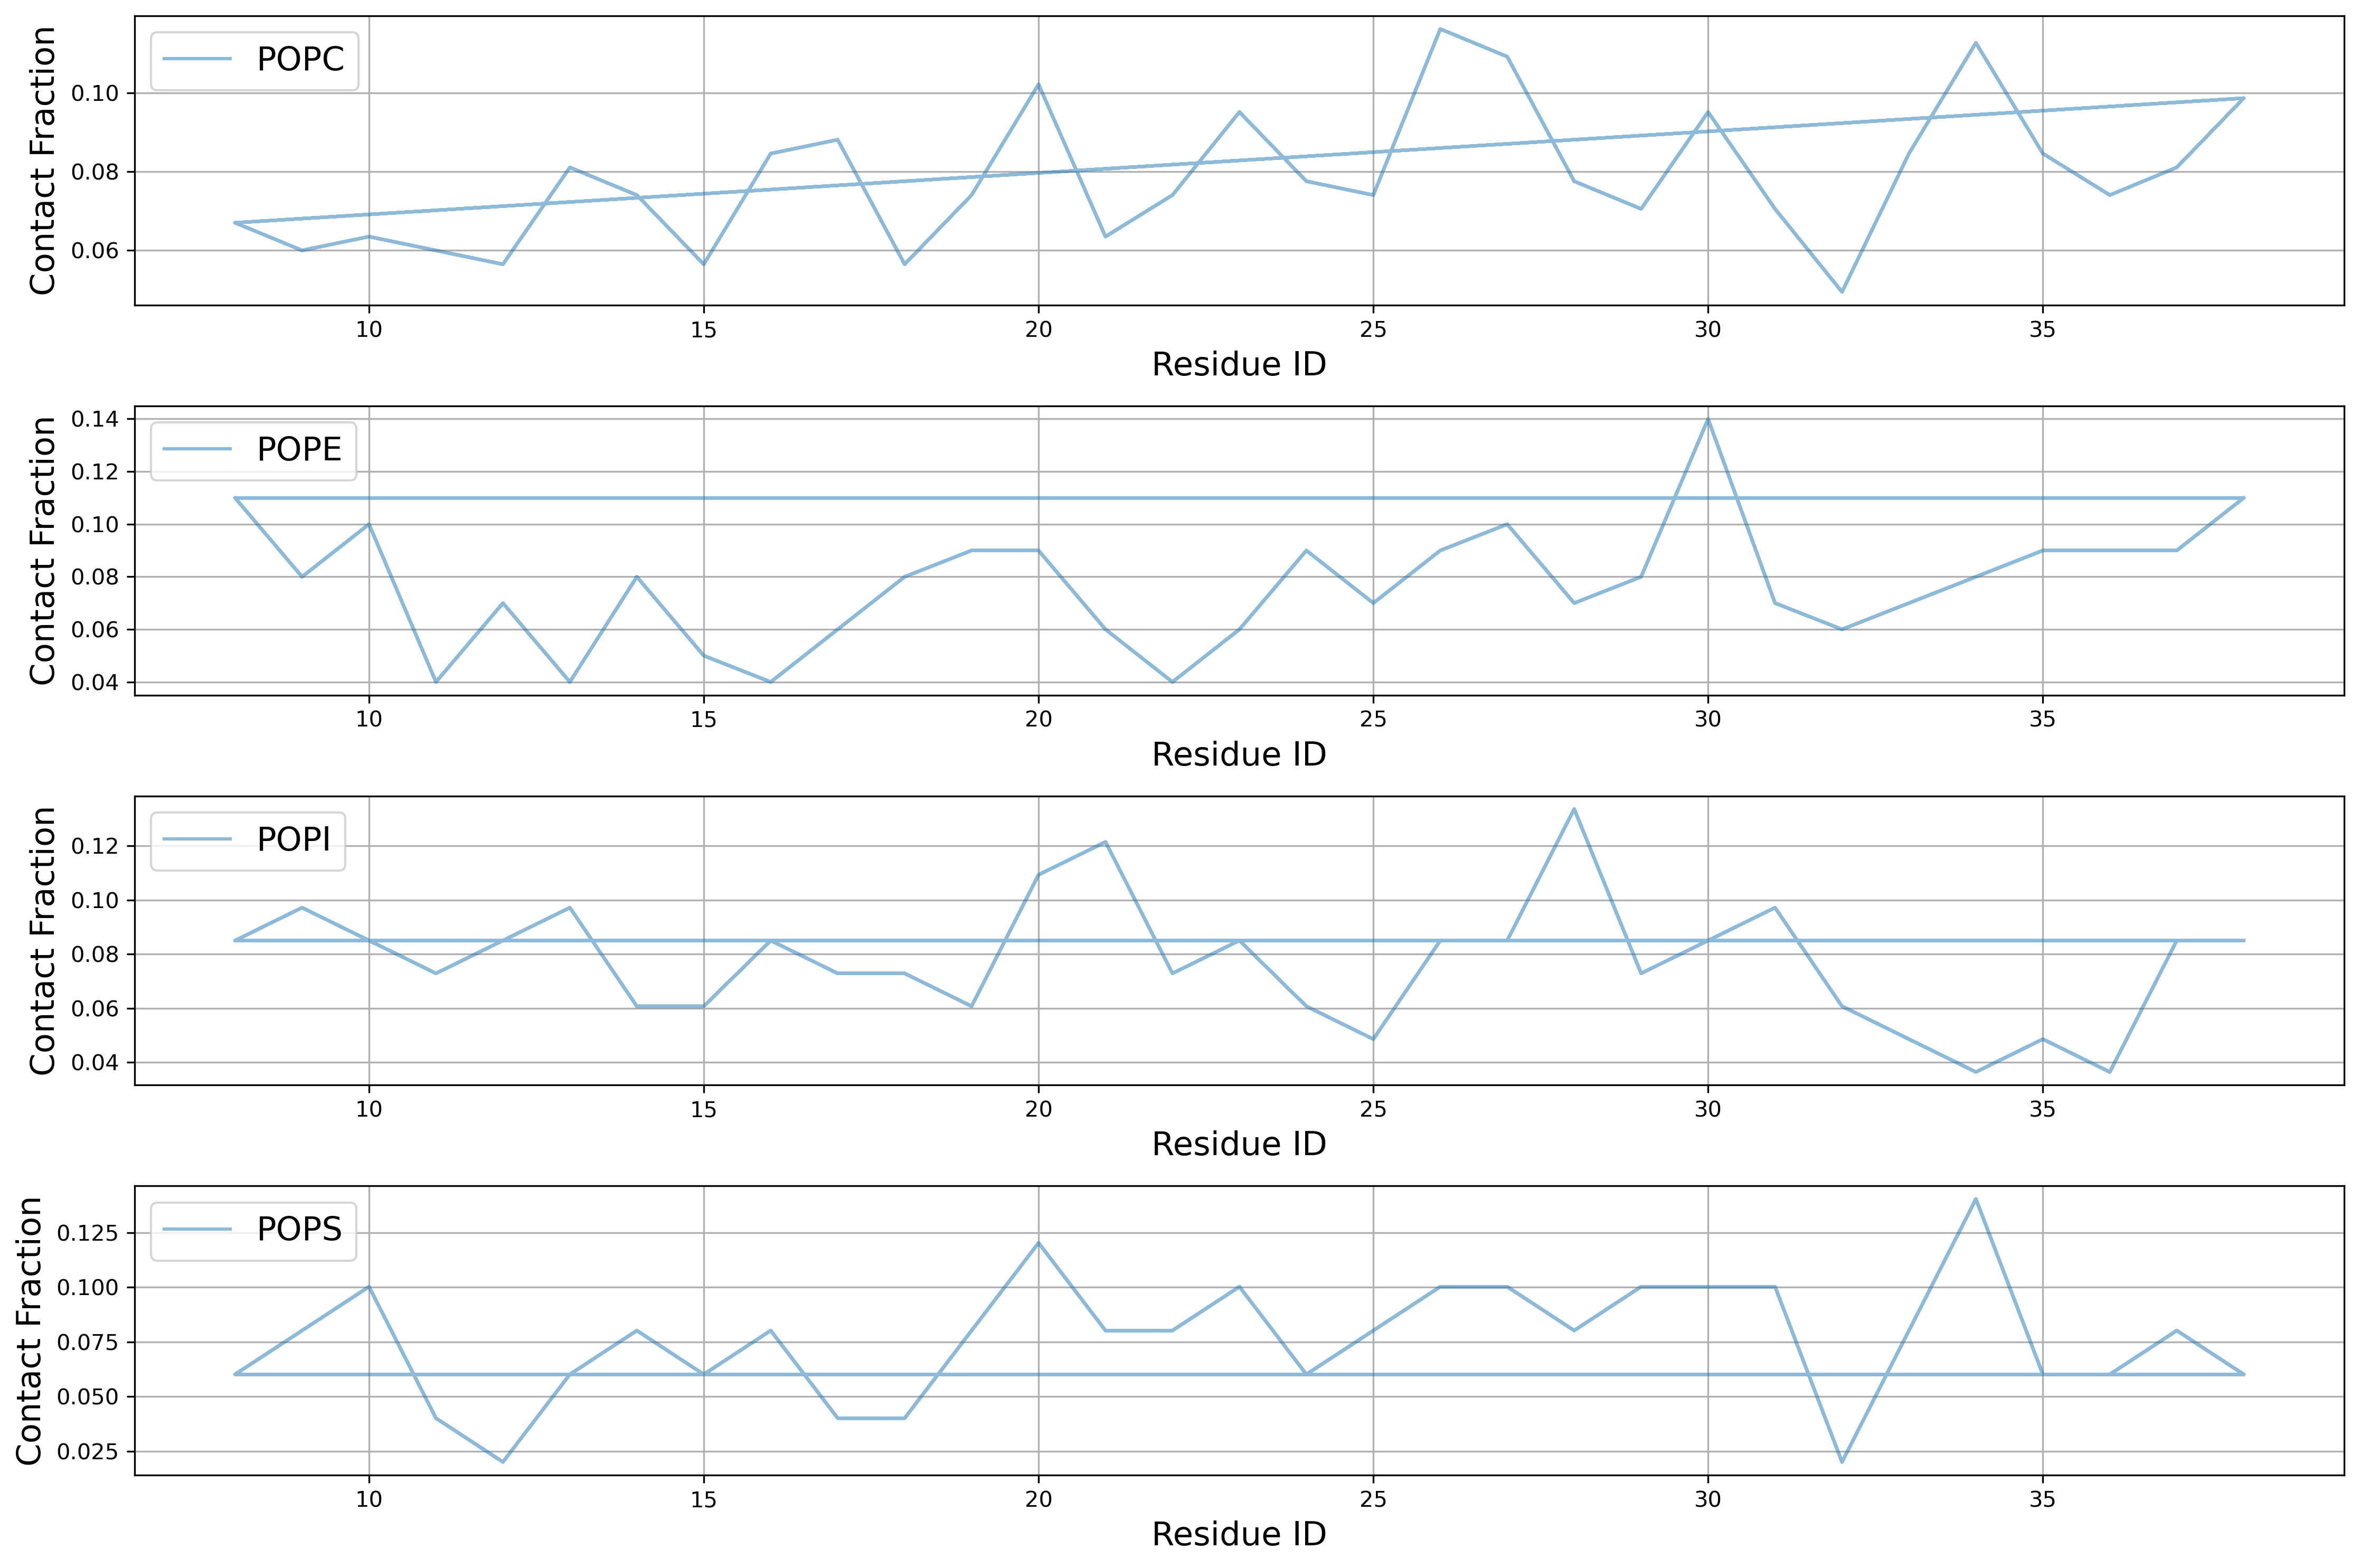

In [35]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing

topology = 'Neutral-with-Ca.pdb'
#trajectory = 'Neutral-without-Calcium.xtc'
u = mda.Universe(topology)

protein_ca_selection = 'protein'

lipids = ['POPC', 'POPE', 'POPI', 'POPS']
cutoff = 10.0

plt.figure(figsize=[15,10],dpi=300)

for idx, lipid in enumerate(lipids, start=1):
    plt.subplot(4, 1, idx)
    
    residue_indices = []
    contact_fractions = []
    
    for residue in u.select_atoms(protein_ca_selection).residues:
        residue_indices.append(residue.resid)
        lipid_selection = u.select_atoms(f"resname {lipid} and around {cutoff} resid {residue.resid}")
        lipid_ids_within_cutoff = set(lipid_selection.resids)
        contact_fraction = len(lipid_ids_within_cutoff) / len(u.select_atoms(f"resname {lipid}").residues)
        contact_fractions.append(contact_fraction)

    normalized_contact_fractions = preprocessing.normalize([np.array(contact_fractions)])[0]
    
    plt.plot(residue_indices, normalized_contact_fractions, alpha=0.5, label=lipid)
    
    plt.xlabel('Residue ID',fontsize=15)
    plt.ylabel('Contact Fraction',fontsize=15)
    plt.legend(loc = "upper left",fontsize=15)
    plt.grid(True)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

ValueError: Found array with 0 feature(s) (shape=(1, 0)) while a minimum of 1 is required by the normalize function.

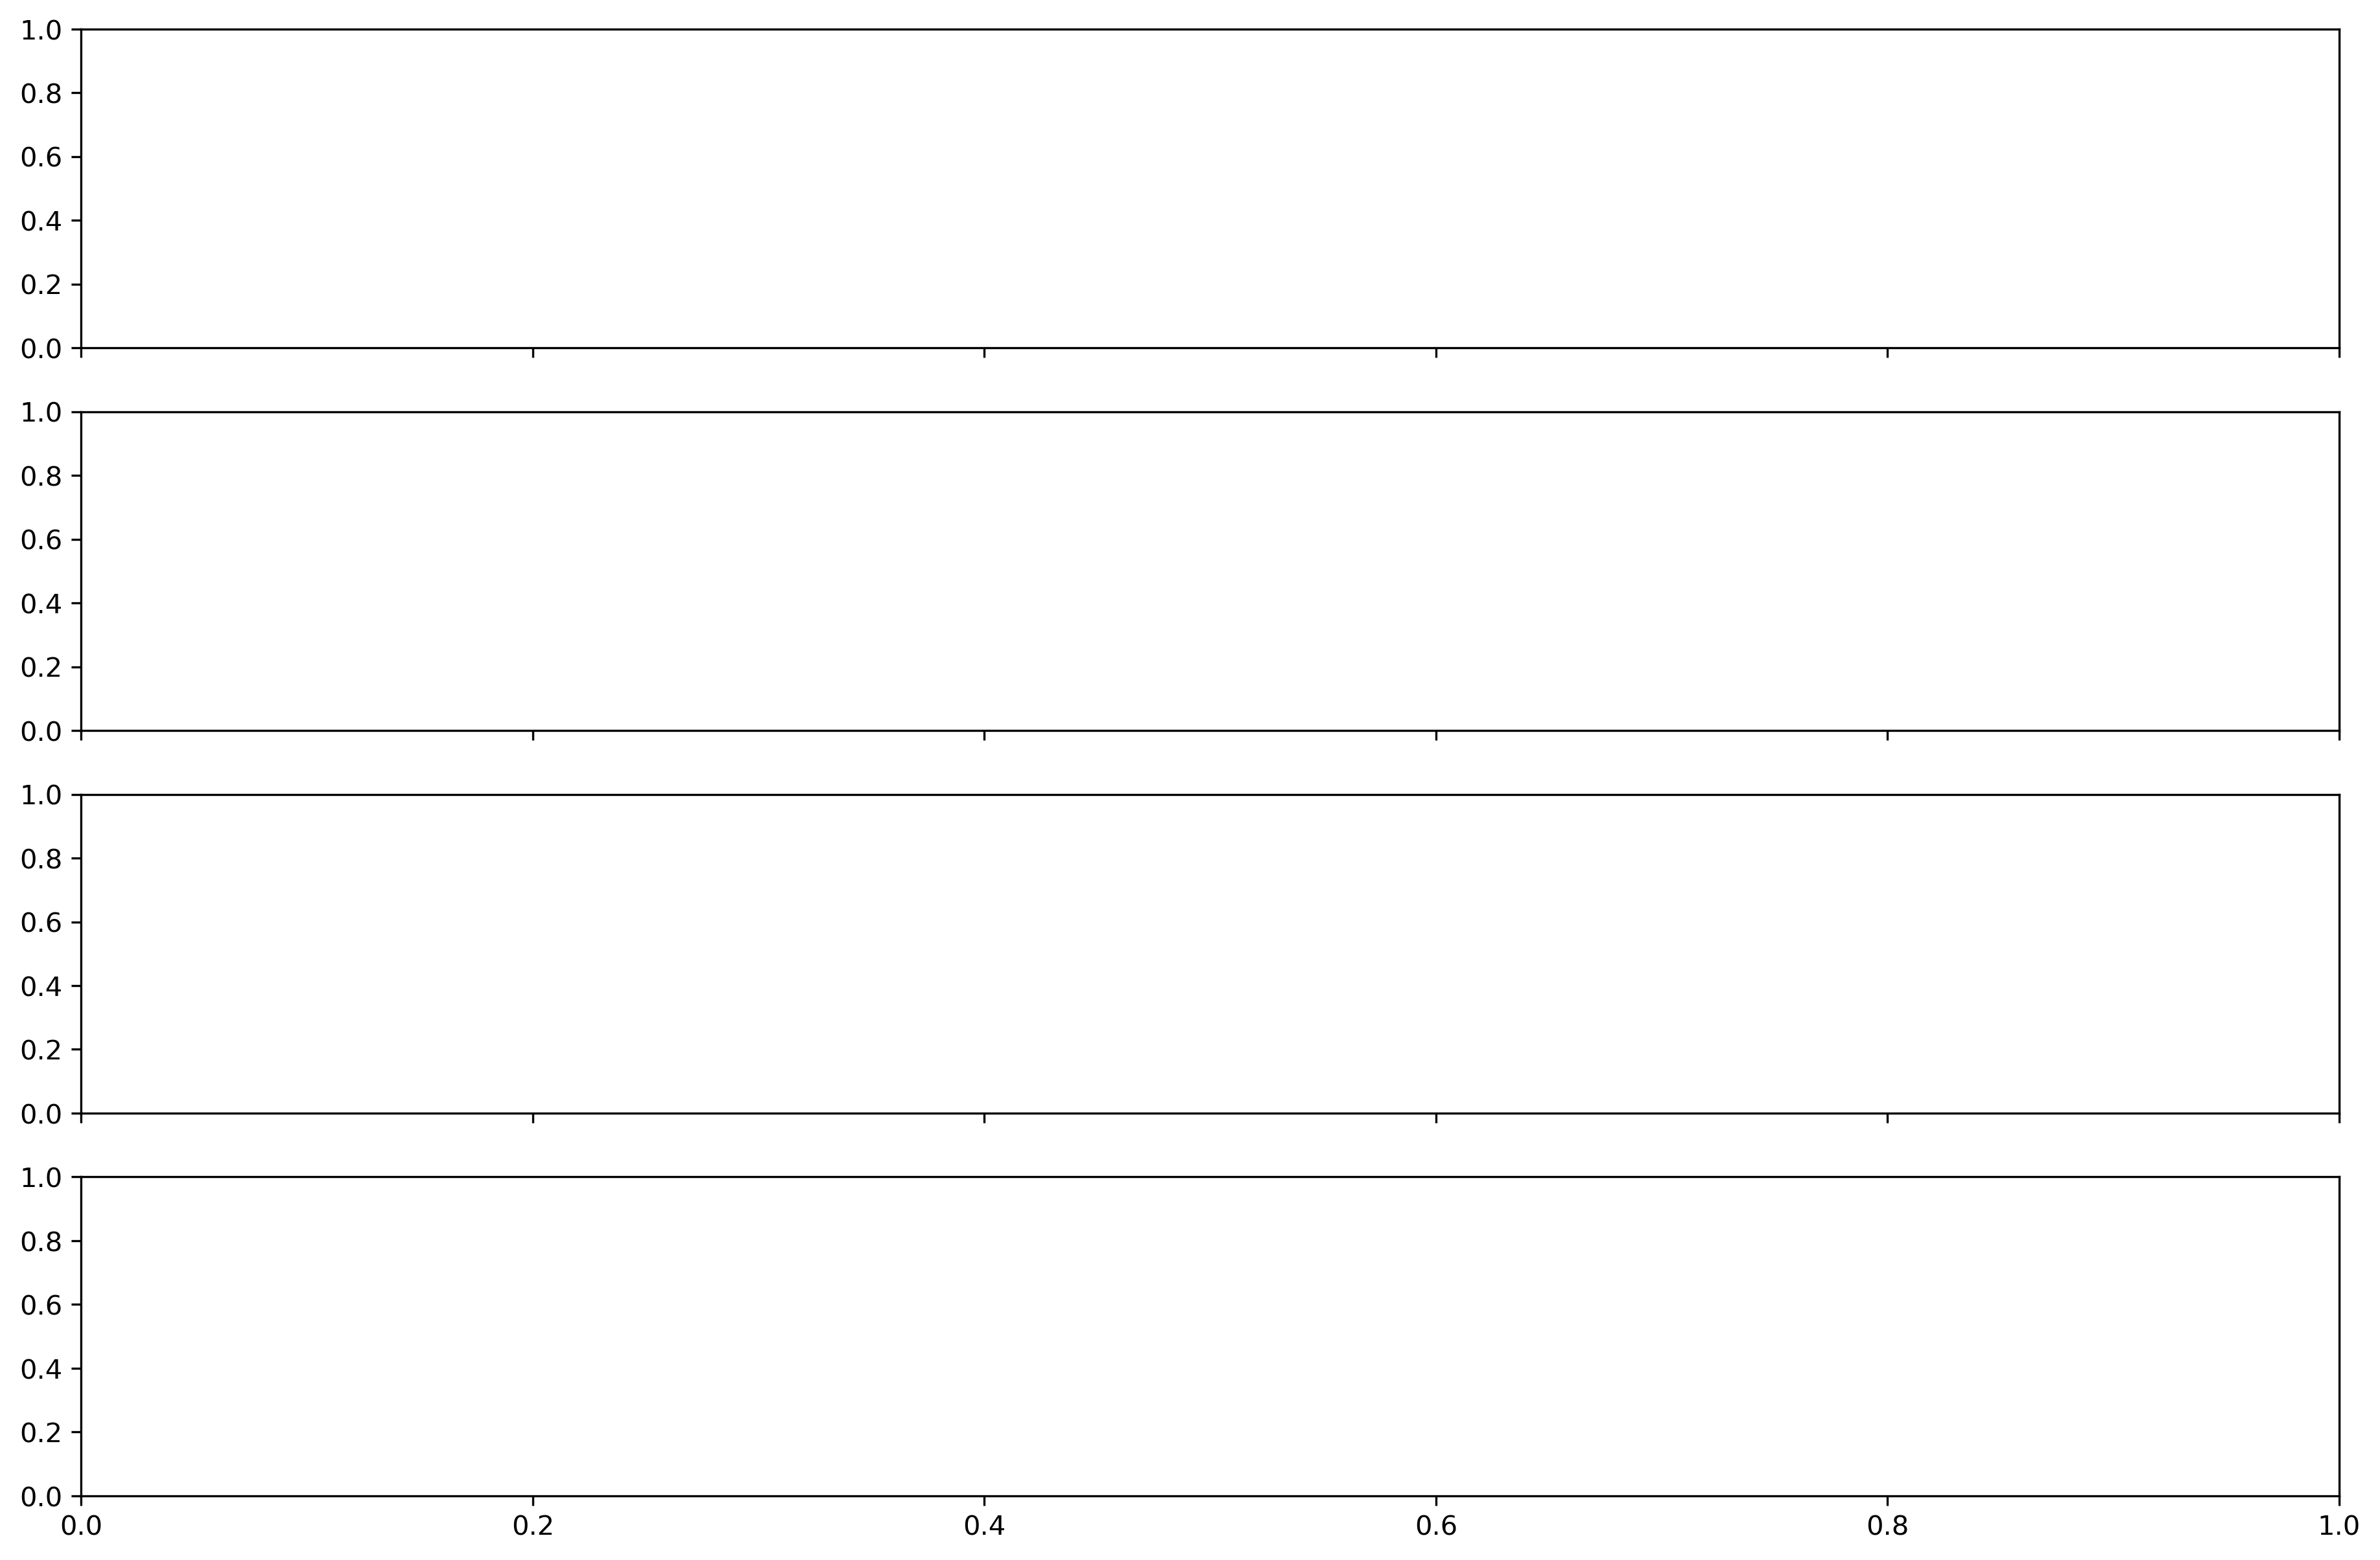

In [5]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing

topology = 'Neutral-without-calcium.gro'
trajectory = 'Neutral-without-Calcium.xtc'
u = mda.Universe(topology, trajectory)

protein_ca_selection = 'protein and segid PROA'

lipids = ['POPC', 'POPE', 'POPI', 'POPS']
cutoff = 10.0

fig, axs = plt.subplots(4, 1, sharex=True, figsize=(15, 10), dpi=300)

for idx, lipid in enumerate(lipids):
    residue_indices = []
    contact_fractions = []
    
    for residue in u.select_atoms(protein_ca_selection).residues:
        residue_indices.append(residue.resid)
        lipid_selection = u.select_atoms(f"resname {lipid} and around {cutoff} resid {residue.resid}")
        lipid_ids_within_cutoff = set(lipid_selection.resids)
        contact_fraction = len(lipid_ids_within_cutoff)
        contact_fractions.append(contact_fraction)

    normalized_contact_fractions = preprocessing.normalize([np.array(contact_fractions)])[0]
    
    axs[idx].plot(residue_indices, normalized_contact_fractions, color = "blue", label=lipid)
    axs[idx].fill_between(residue_indices, normalized_contact_fractions, alpha=0.3)
    axs[idx].set_ylabel('Contact Fraction',fontsize=18)
    axs[idx].legend(loc="upper left", fontsize=16)
    axs[idx].grid(True)
    axs[idx].tick_params(axis='both', which='major', labelsize=20)

axs[3].set_xlabel('Residue ID', fontsize=20)
plt.suptitle("Neutral without calcium",fontsize=22)
plt.tight_layout()
#plt.savefig('Neutral_without_calcium_contact_fraction.png',dpi=300,bbox_inches='tight')
plt.show()
print(residue_indices)

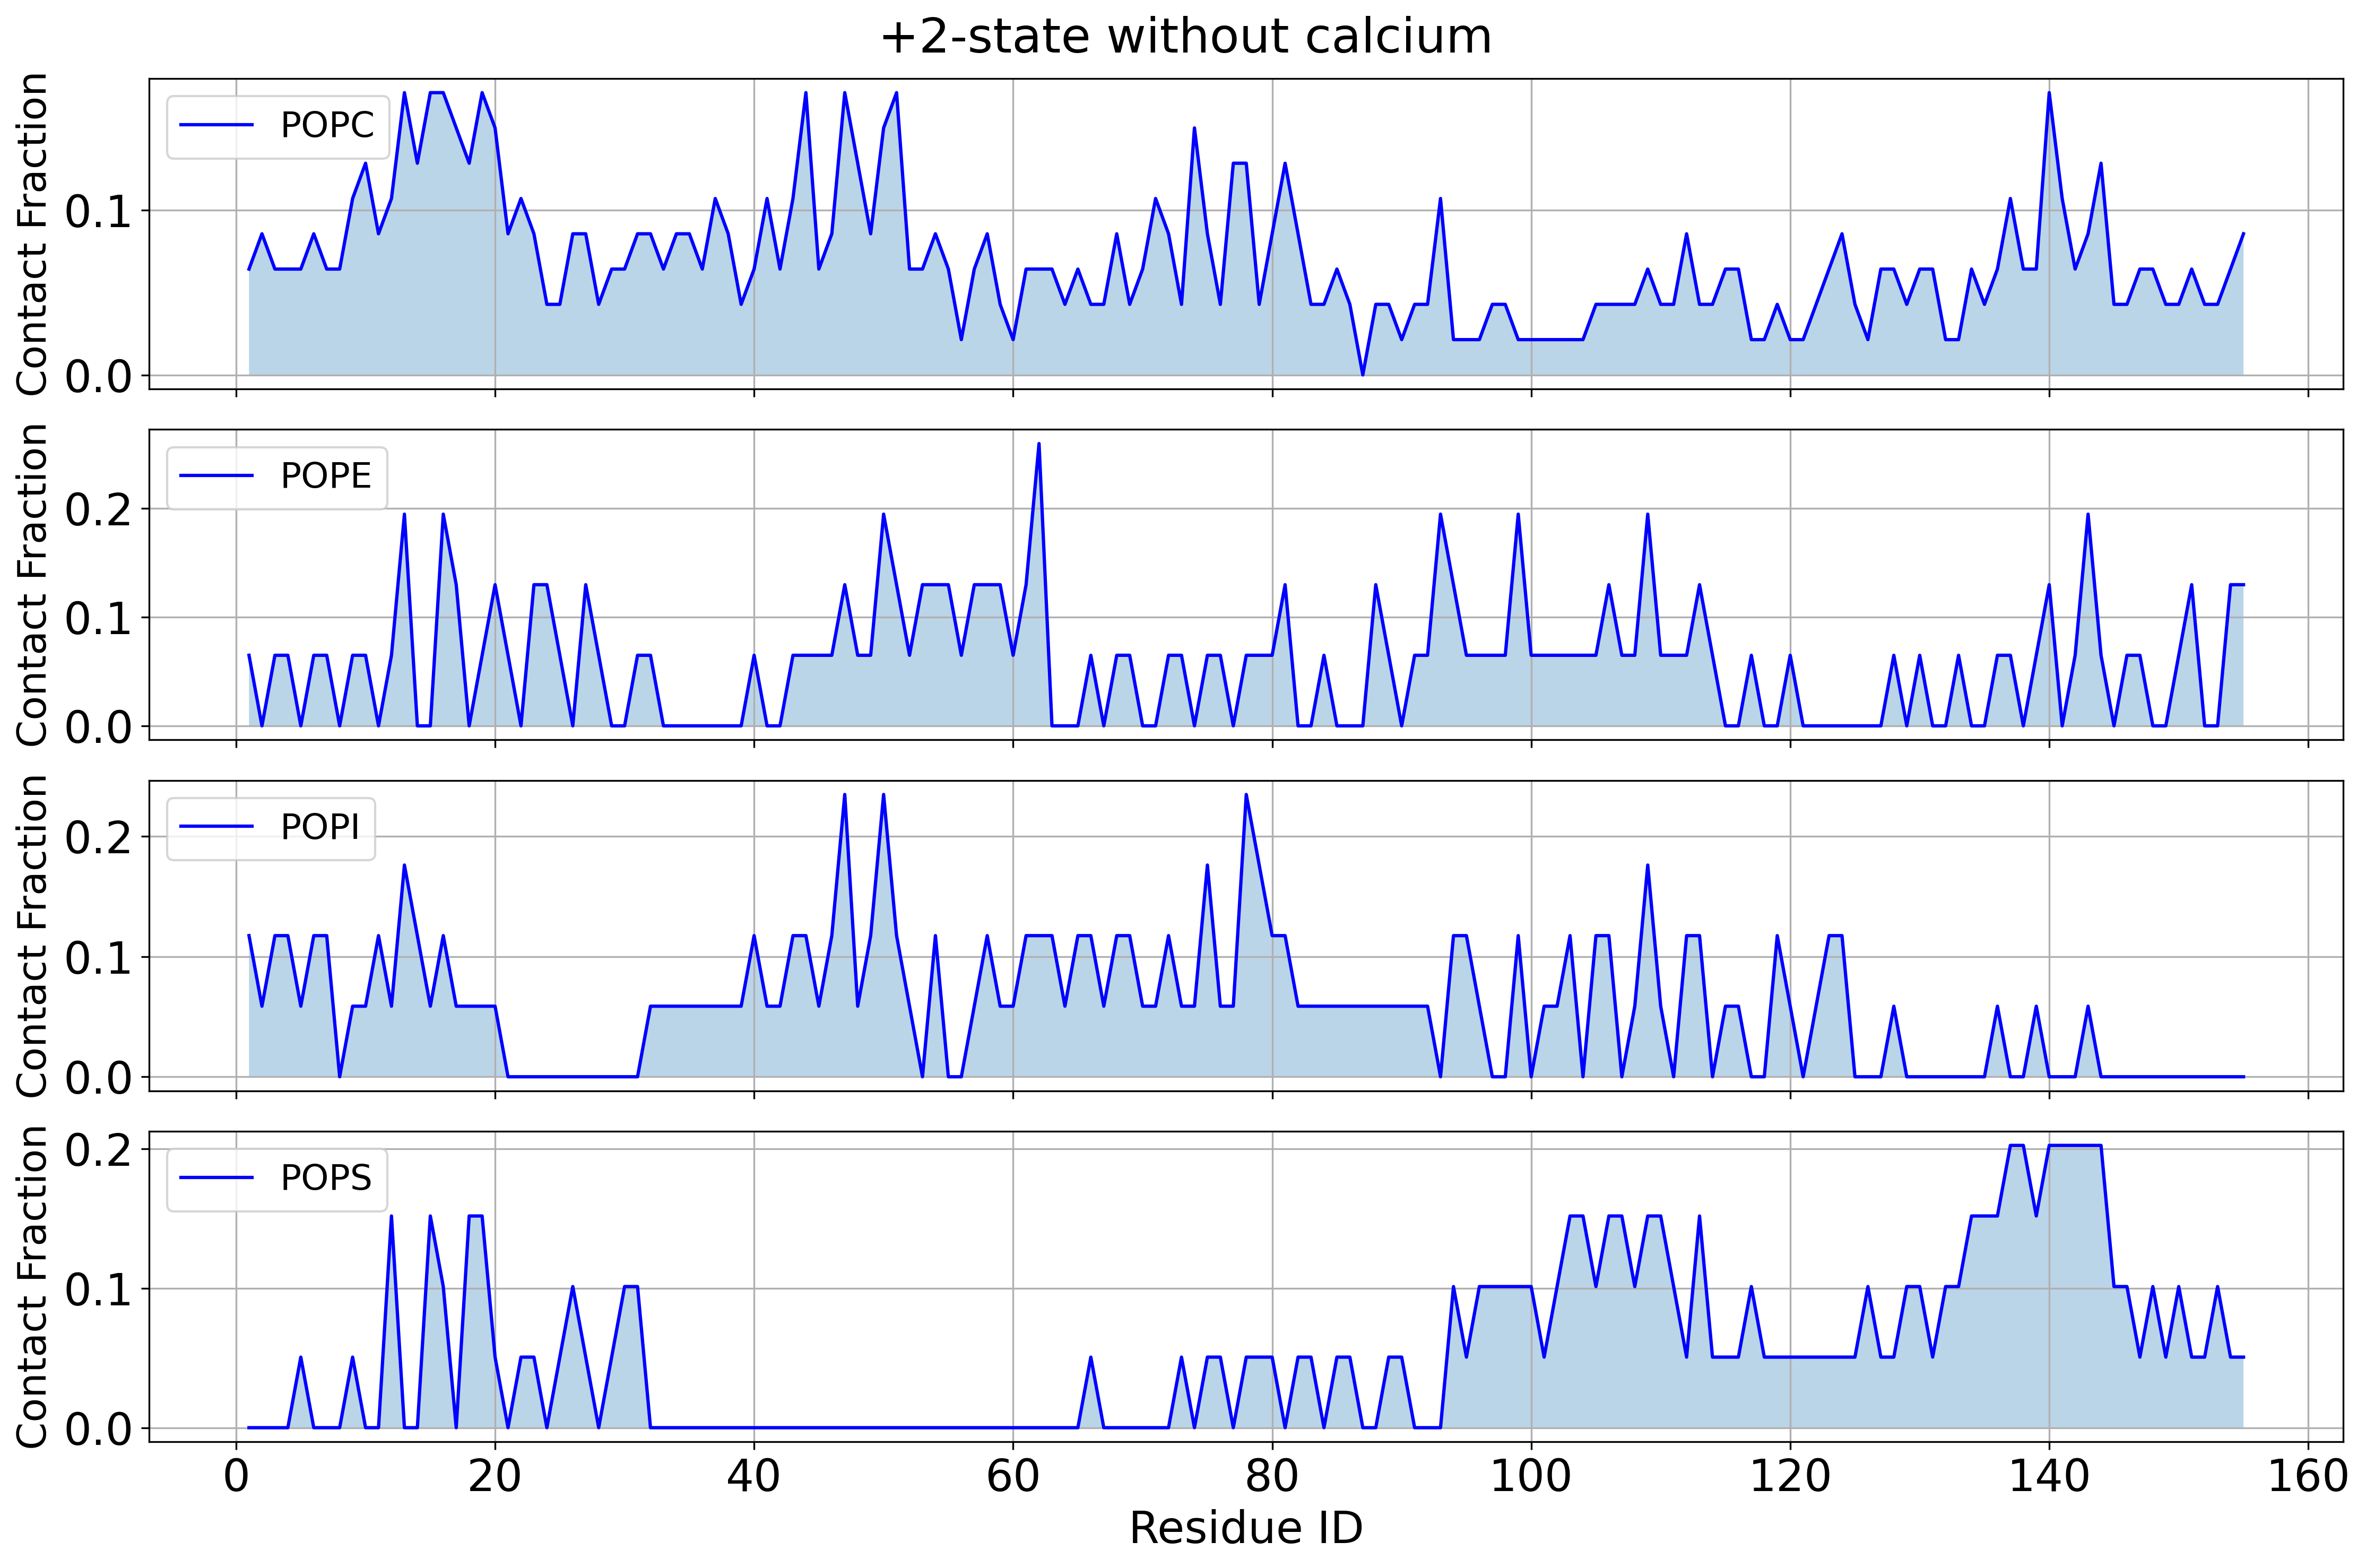

In [249]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing

topology = '+2-without-calcium.gro'
u = mda.Universe(topology)

protein_ca_selection = 'protein and name CA'

lipids = ['POPC', 'POPE', 'POPI', 'POPS']
cutoff = 10.0

fig, axs = plt.subplots(4, 1, sharex=True, figsize=(15, 10), dpi=300)  # Create subplots

for idx, lipid in enumerate(lipids):
    residue_indices = []
    contact_fractions = []
    
    for residue in u.select_atoms(protein_ca_selection).residues:
        residue_indices.append(residue.resid)
        lipid_selection = u.select_atoms(f"resname {lipid} and around {cutoff} resid {residue.resid}")
        lipid_ids_within_cutoff = set(lipid_selection.resids)
        contact_fraction = len(lipid_ids_within_cutoff) / len(u.select_atoms(f"resname {lipid}").residues)
        contact_fractions.append(contact_fraction)

    normalized_contact_fractions = preprocessing.normalize([np.array(contact_fractions)])[0]
    
    axs[idx].plot(residue_indices, normalized_contact_fractions, color = "blue", label=lipid)
    axs[idx].fill_between(residue_indices, normalized_contact_fractions, alpha=0.3)
    axs[idx].set_ylabel('Contact Fraction',fontsize=18)
    axs[idx].legend(loc="upper left", fontsize=16)
    axs[idx].grid(True)
    axs[idx].tick_params(axis='both', which='major', labelsize=20)

axs[3].set_xlabel('Residue ID', fontsize=20)
plt.suptitle("+2-state without calcium",fontsize=22)
plt.tight_layout()
plt.savefig('+2_without_calcium_contact_fraction.png',dpi=300,bbox_inches='tight')
plt.show()

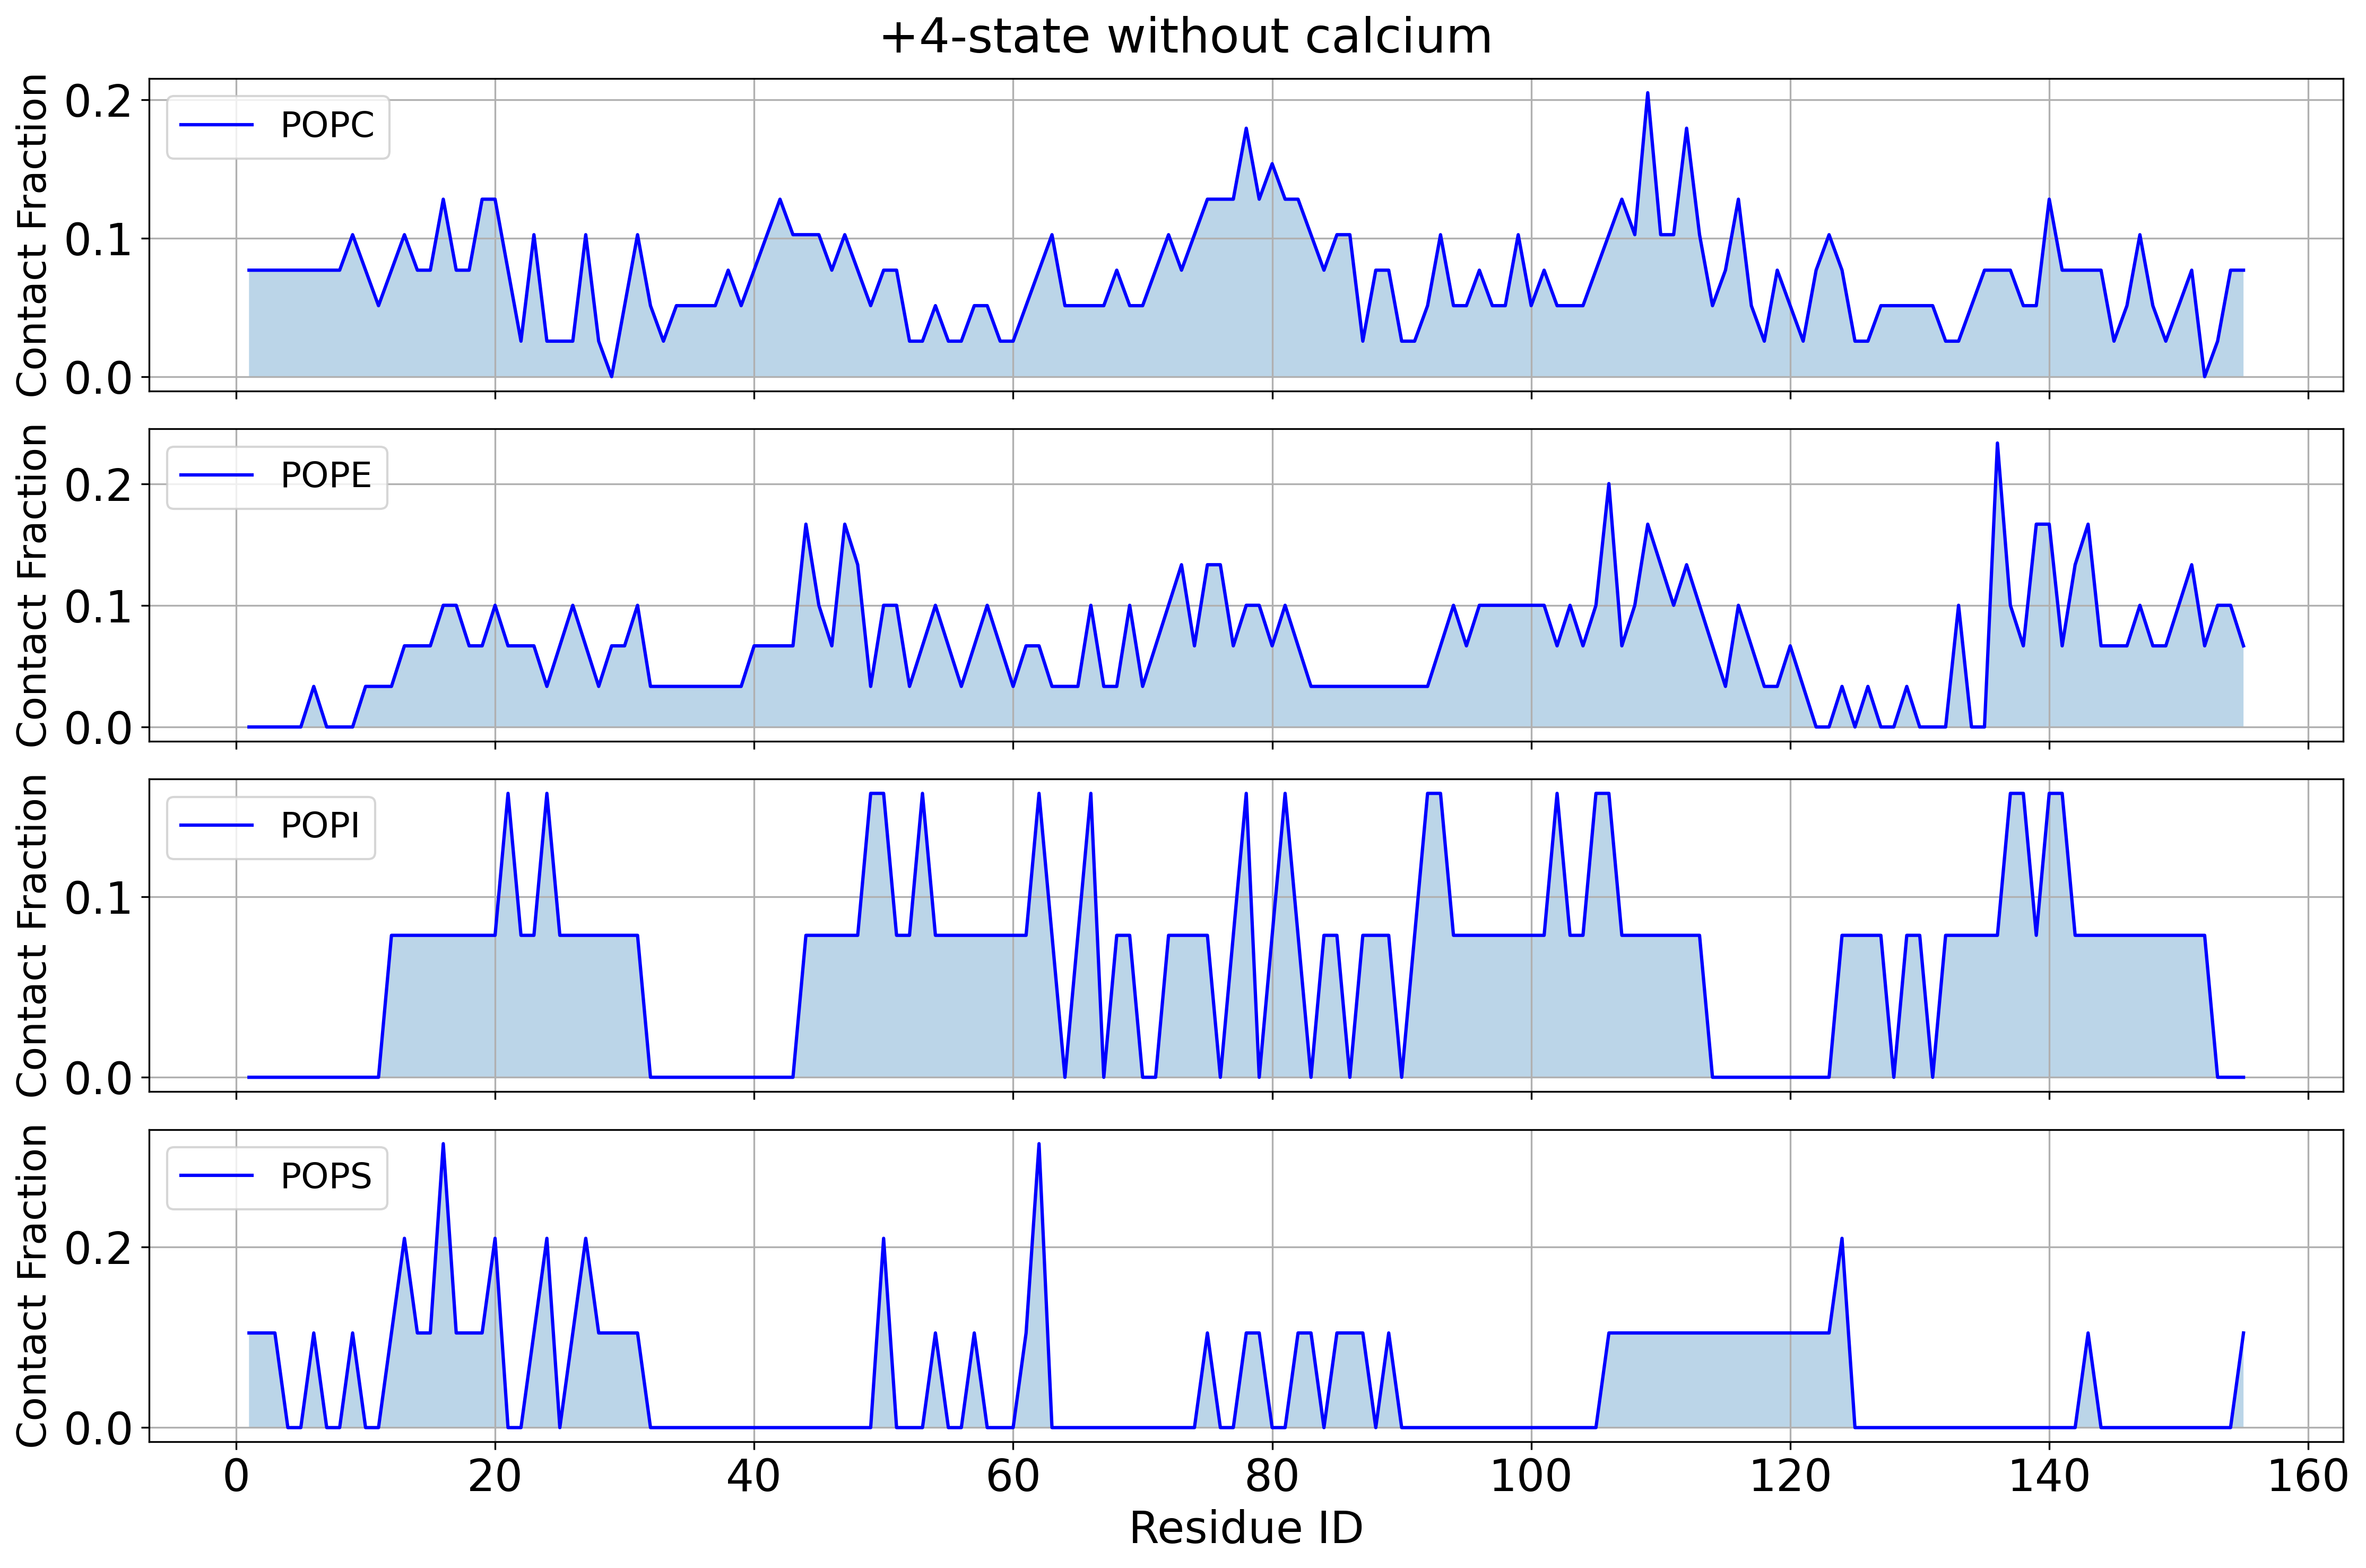

In [250]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing

topology = '+4-without-calcium.gro'
u = mda.Universe(topology)

protein_ca_selection = 'protein and name CA'

lipids = ['POPC', 'POPE', 'POPI', 'POPS']
cutoff = 10.0

fig, axs = plt.subplots(4, 1, sharex=True, figsize=(15, 10), dpi=300)  # Create subplots

for idx, lipid in enumerate(lipids):
    residue_indices = []
    contact_fractions = []
    
    for residue in u.select_atoms(protein_ca_selection).residues:
        residue_indices.append(residue.resid)
        lipid_selection = u.select_atoms(f"resname {lipid} and around {cutoff} resid {residue.resid}")
        lipid_ids_within_cutoff = set(lipid_selection.resids)
        contact_fraction = len(lipid_ids_within_cutoff) / len(u.select_atoms(f"resname {lipid}").residues)
        contact_fractions.append(contact_fraction)

    normalized_contact_fractions = preprocessing.normalize([np.array(contact_fractions)])[0]
    
    axs[idx].plot(residue_indices, normalized_contact_fractions, color = "blue", label=lipid)
    axs[idx].fill_between(residue_indices, normalized_contact_fractions, alpha=0.3)
    axs[idx].set_ylabel('Contact Fraction',fontsize=18)
    axs[idx].legend(loc="upper left", fontsize=16)
    axs[idx].grid(True)
    axs[idx].tick_params(axis='both', which='major', labelsize=20)

axs[3].set_xlabel('Residue ID', fontsize=20)
plt.suptitle("+4-state without calcium",fontsize=22)
plt.tight_layout()
plt.savefig('+4_without_calcium_contact_fraction.png',dpi=300,bbox_inches='tight')
plt.show()

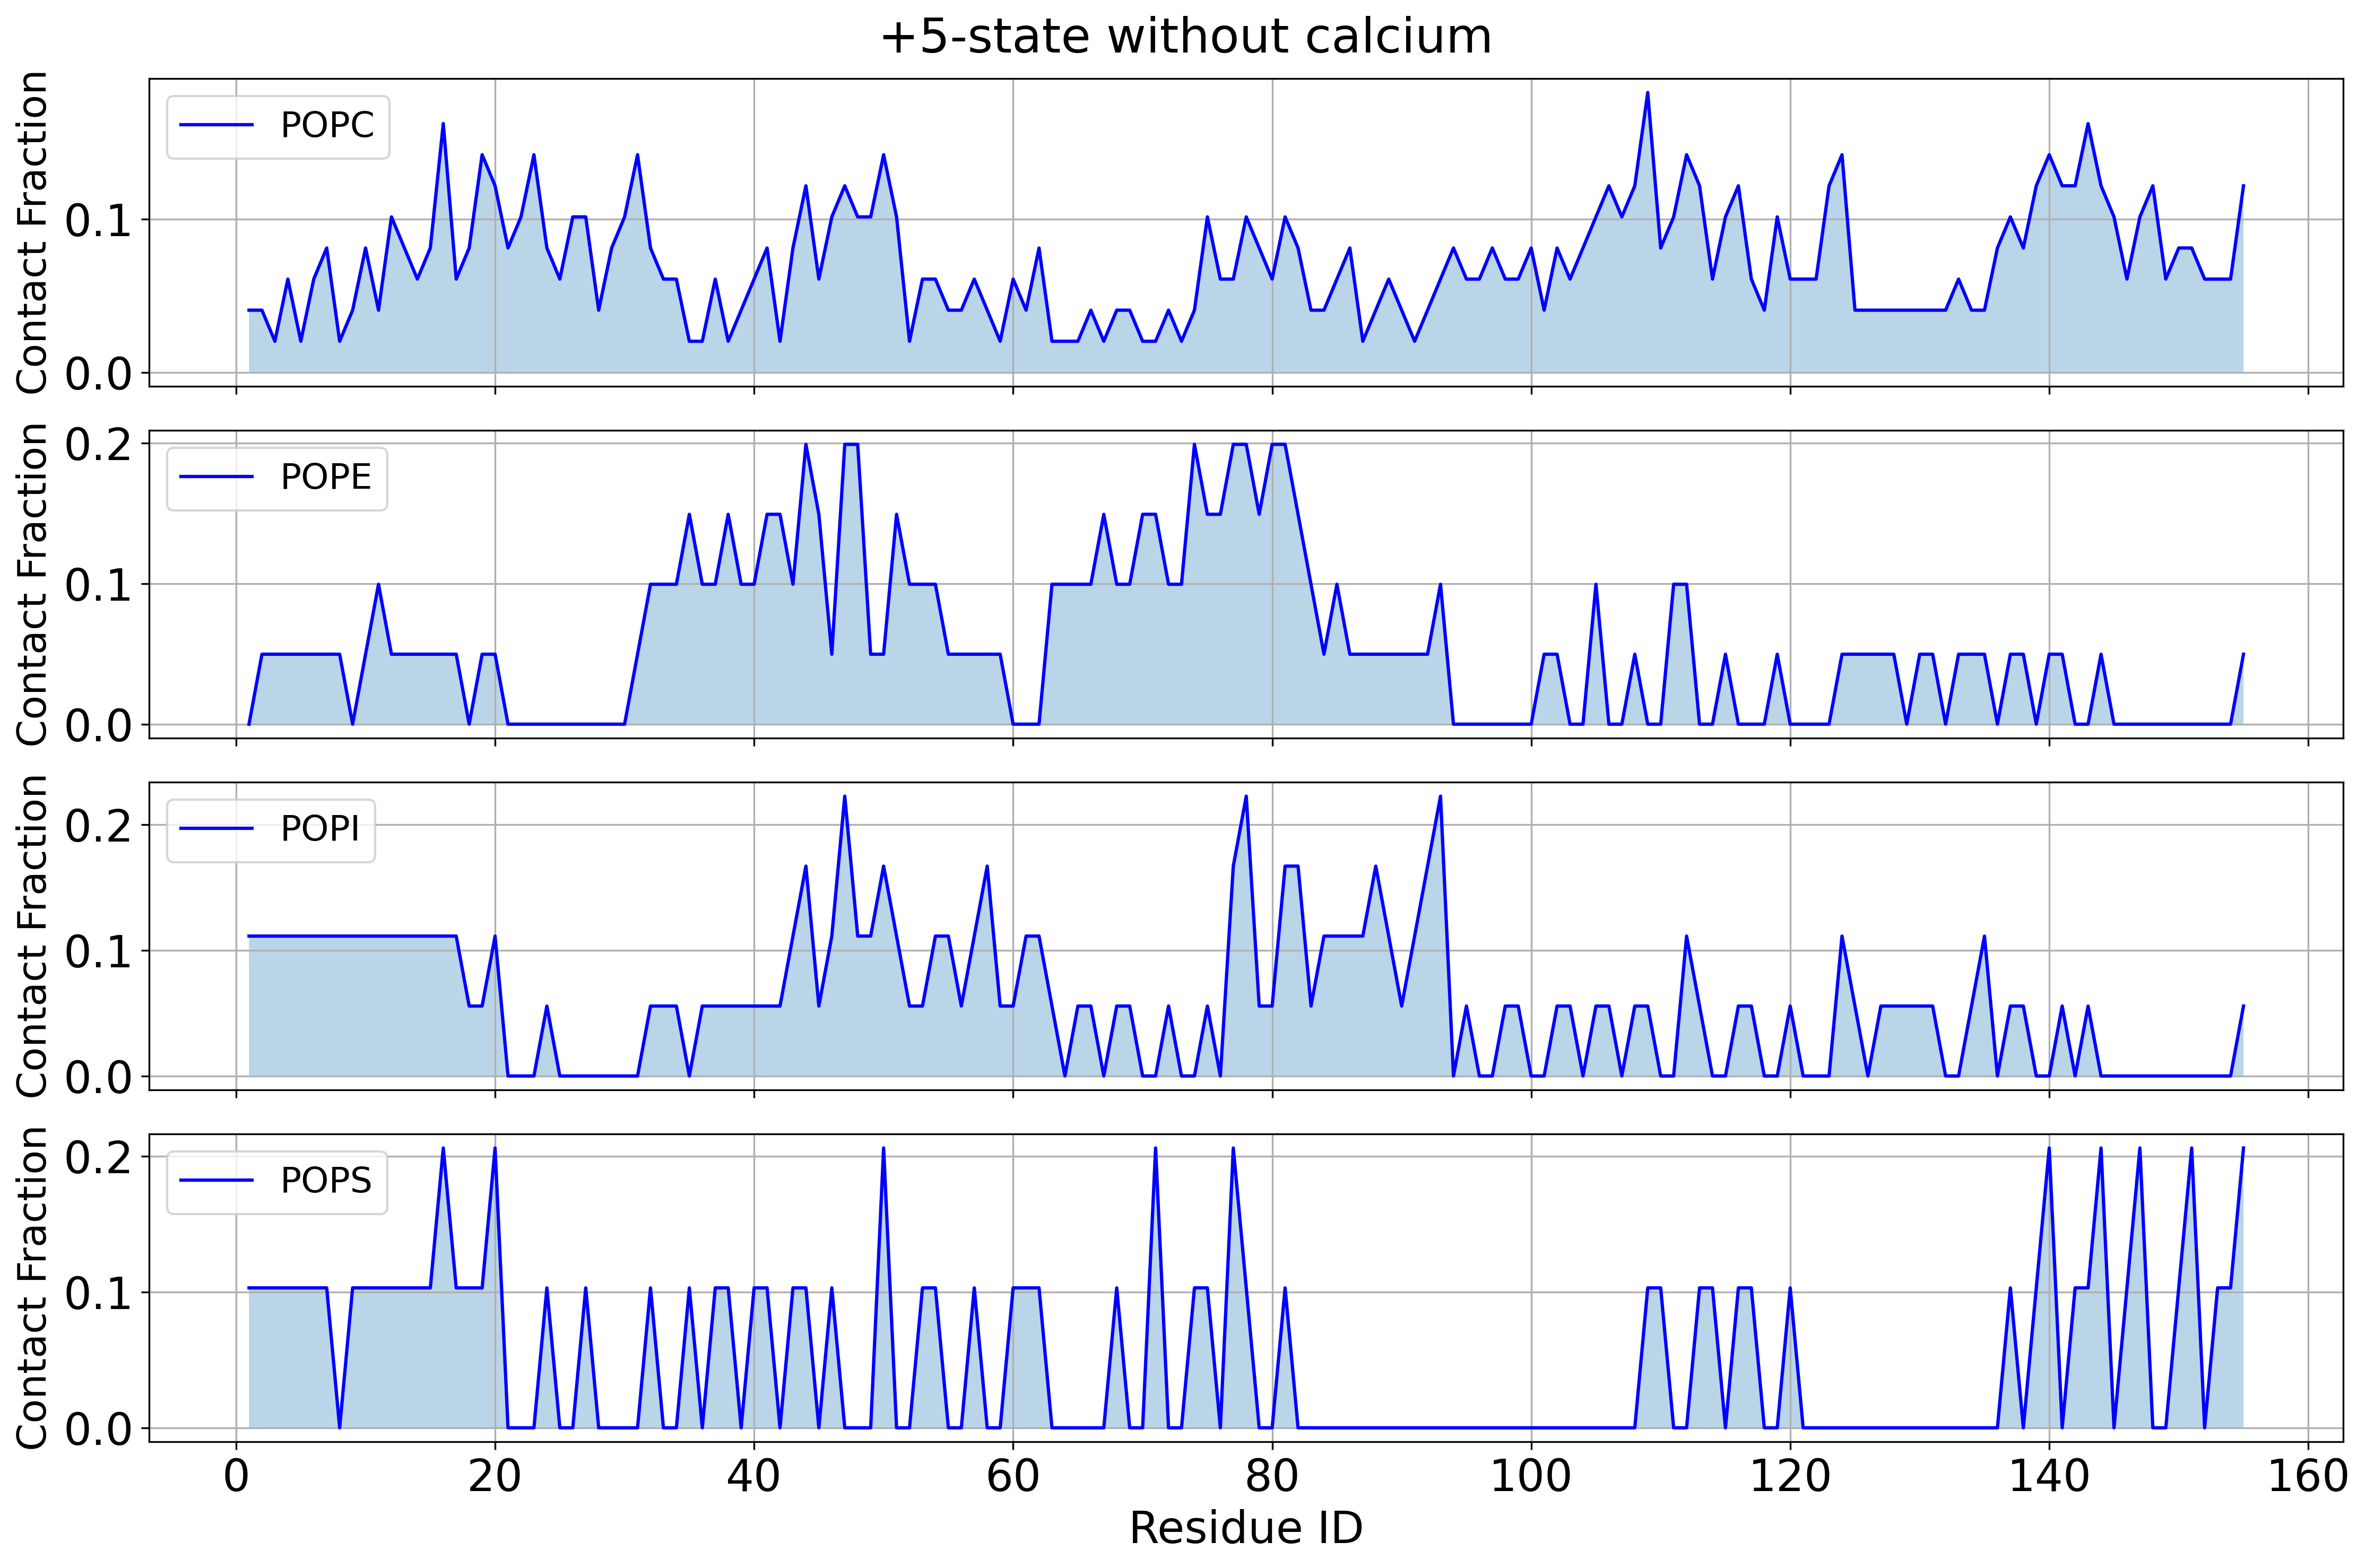

In [251]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing

topology = '+5-without-calcium.gro'
u = mda.Universe(topology)

protein_ca_selection = 'protein and name CA'

lipids = ['POPC', 'POPE', 'POPI', 'POPS']
cutoff = 10.0

fig, axs = plt.subplots(4, 1, sharex=True, figsize=(15, 10), dpi=300)  # Create subplots

for idx, lipid in enumerate(lipids):
    residue_indices = []
    contact_fractions = []
    
    for residue in u.select_atoms(protein_ca_selection).residues:
        residue_indices.append(residue.resid)
        lipid_selection = u.select_atoms(f"resname {lipid} and around {cutoff} resid {residue.resid}")
        lipid_ids_within_cutoff = set(lipid_selection.resids)
        contact_fraction = len(lipid_ids_within_cutoff) / len(u.select_atoms(f"resname {lipid}").residues)
        contact_fractions.append(contact_fraction)

    normalized_contact_fractions = preprocessing.normalize([np.array(contact_fractions)])[0]
    
    axs[idx].plot(residue_indices, normalized_contact_fractions, color = "blue", label=lipid)
    axs[idx].fill_between(residue_indices, normalized_contact_fractions, alpha=0.3)
    axs[idx].set_ylabel('Contact Fraction',fontsize=18)
    axs[idx].legend(loc="upper left", fontsize=16)
    axs[idx].grid(True)
    axs[idx].tick_params(axis='both', which='major', labelsize=20)

axs[3].set_xlabel('Residue ID', fontsize=20)
plt.suptitle("+5-state without calcium",fontsize=22)
plt.tight_layout()
plt.savefig('+5_without_calcium_contact_fraction.png',dpi=300,bbox_inches='tight')
plt.show()

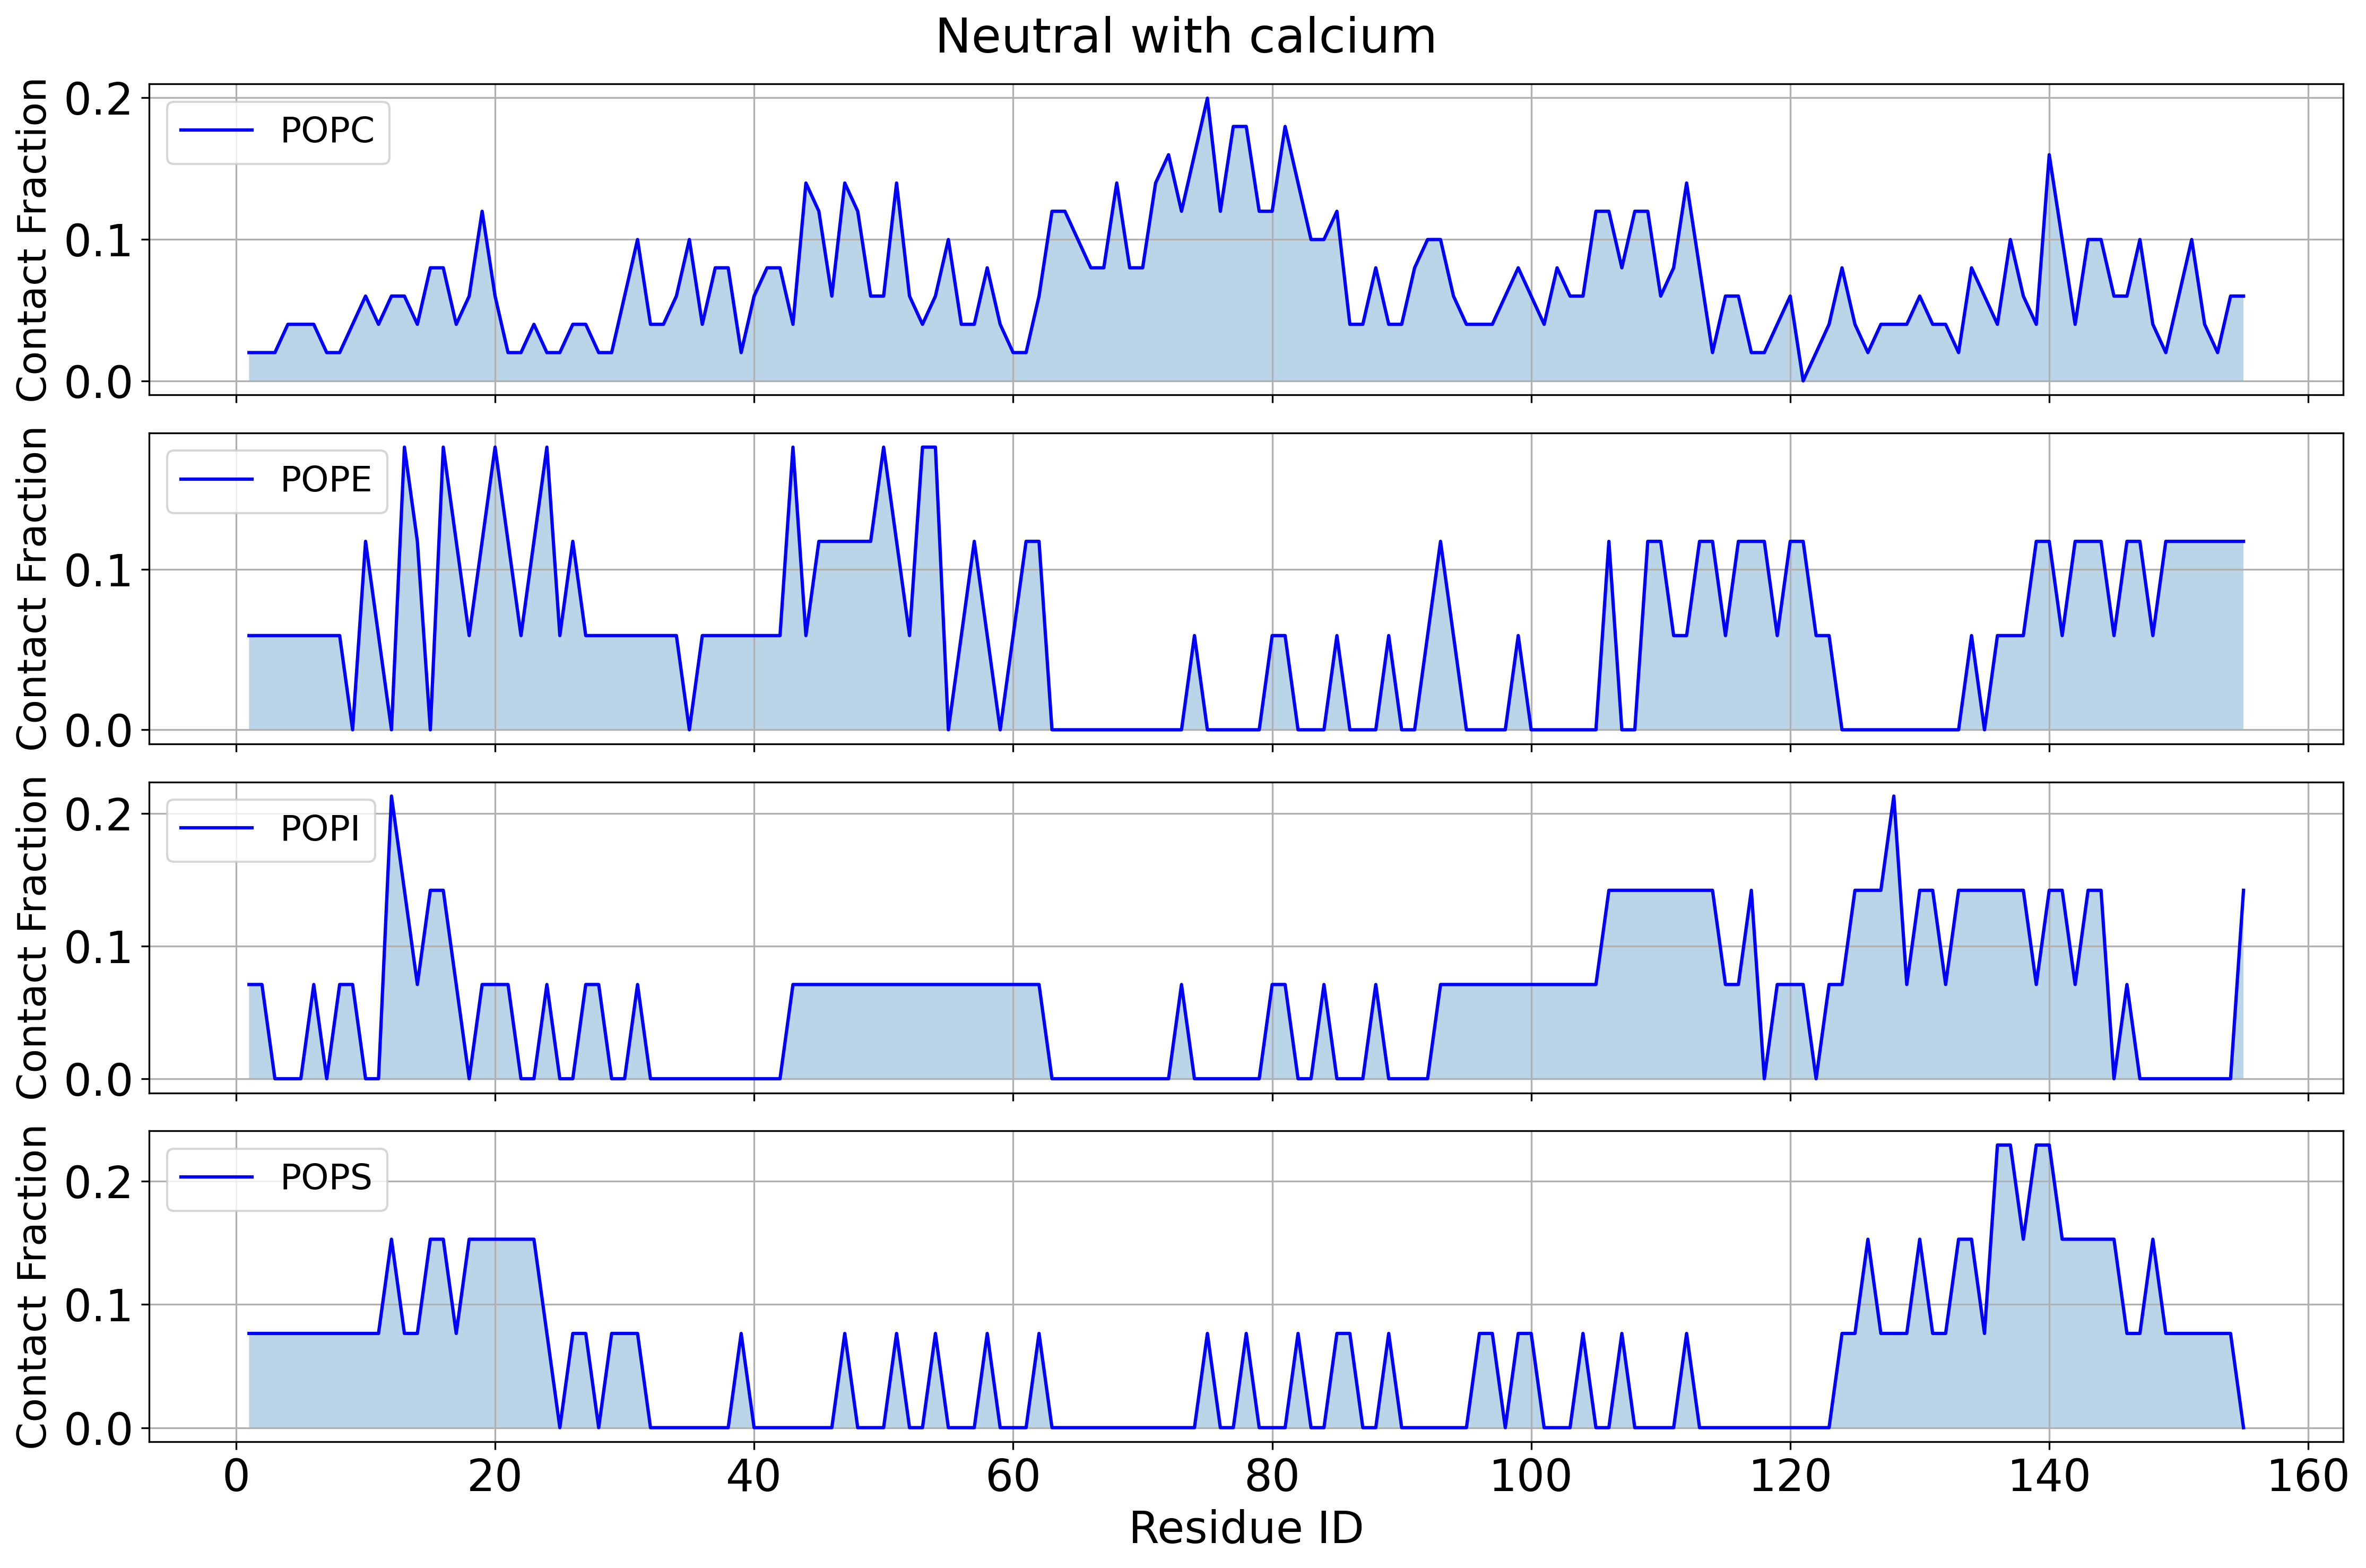

In [252]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing

topology = 'Neutral-with-Ca.gro'
u = mda.Universe(topology)

protein_ca_selection = 'protein and name CA'

lipids = ['POPC', 'POPE', 'POPI', 'POPS']
cutoff = 10.0

fig, axs = plt.subplots(4, 1, sharex=True, figsize=(15, 10), dpi=300)  # Create subplots

for idx, lipid in enumerate(lipids):
    residue_indices = []
    contact_fractions = []
    
    for residue in u.select_atoms(protein_ca_selection).residues:
        residue_indices.append(residue.resid)
        lipid_selection = u.select_atoms(f"resname {lipid} and around {cutoff} resid {residue.resid}")
        lipid_ids_within_cutoff = set(lipid_selection.resids)
        contact_fraction = len(lipid_ids_within_cutoff) / len(u.select_atoms(f"resname {lipid}").residues)
        contact_fractions.append(contact_fraction)

    normalized_contact_fractions = preprocessing.normalize([np.array(contact_fractions)])[0]
    
    axs[idx].plot(residue_indices, normalized_contact_fractions, color = "blue", label=lipid)
    axs[idx].fill_between(residue_indices, normalized_contact_fractions, alpha=0.3)
    axs[idx].set_ylabel('Contact Fraction',fontsize=18)
    axs[idx].legend(loc="upper left", fontsize=16)
    axs[idx].grid(True)
    axs[idx].tick_params(axis='both', which='major', labelsize=20)

axs[3].set_xlabel('Residue ID', fontsize=20)
plt.suptitle("Neutral with calcium",fontsize=22)
plt.tight_layout()
plt.savefig('Neutral_with_calcium_contact_fraction.png',dpi=300,bbox_inches='tight')
plt.show()

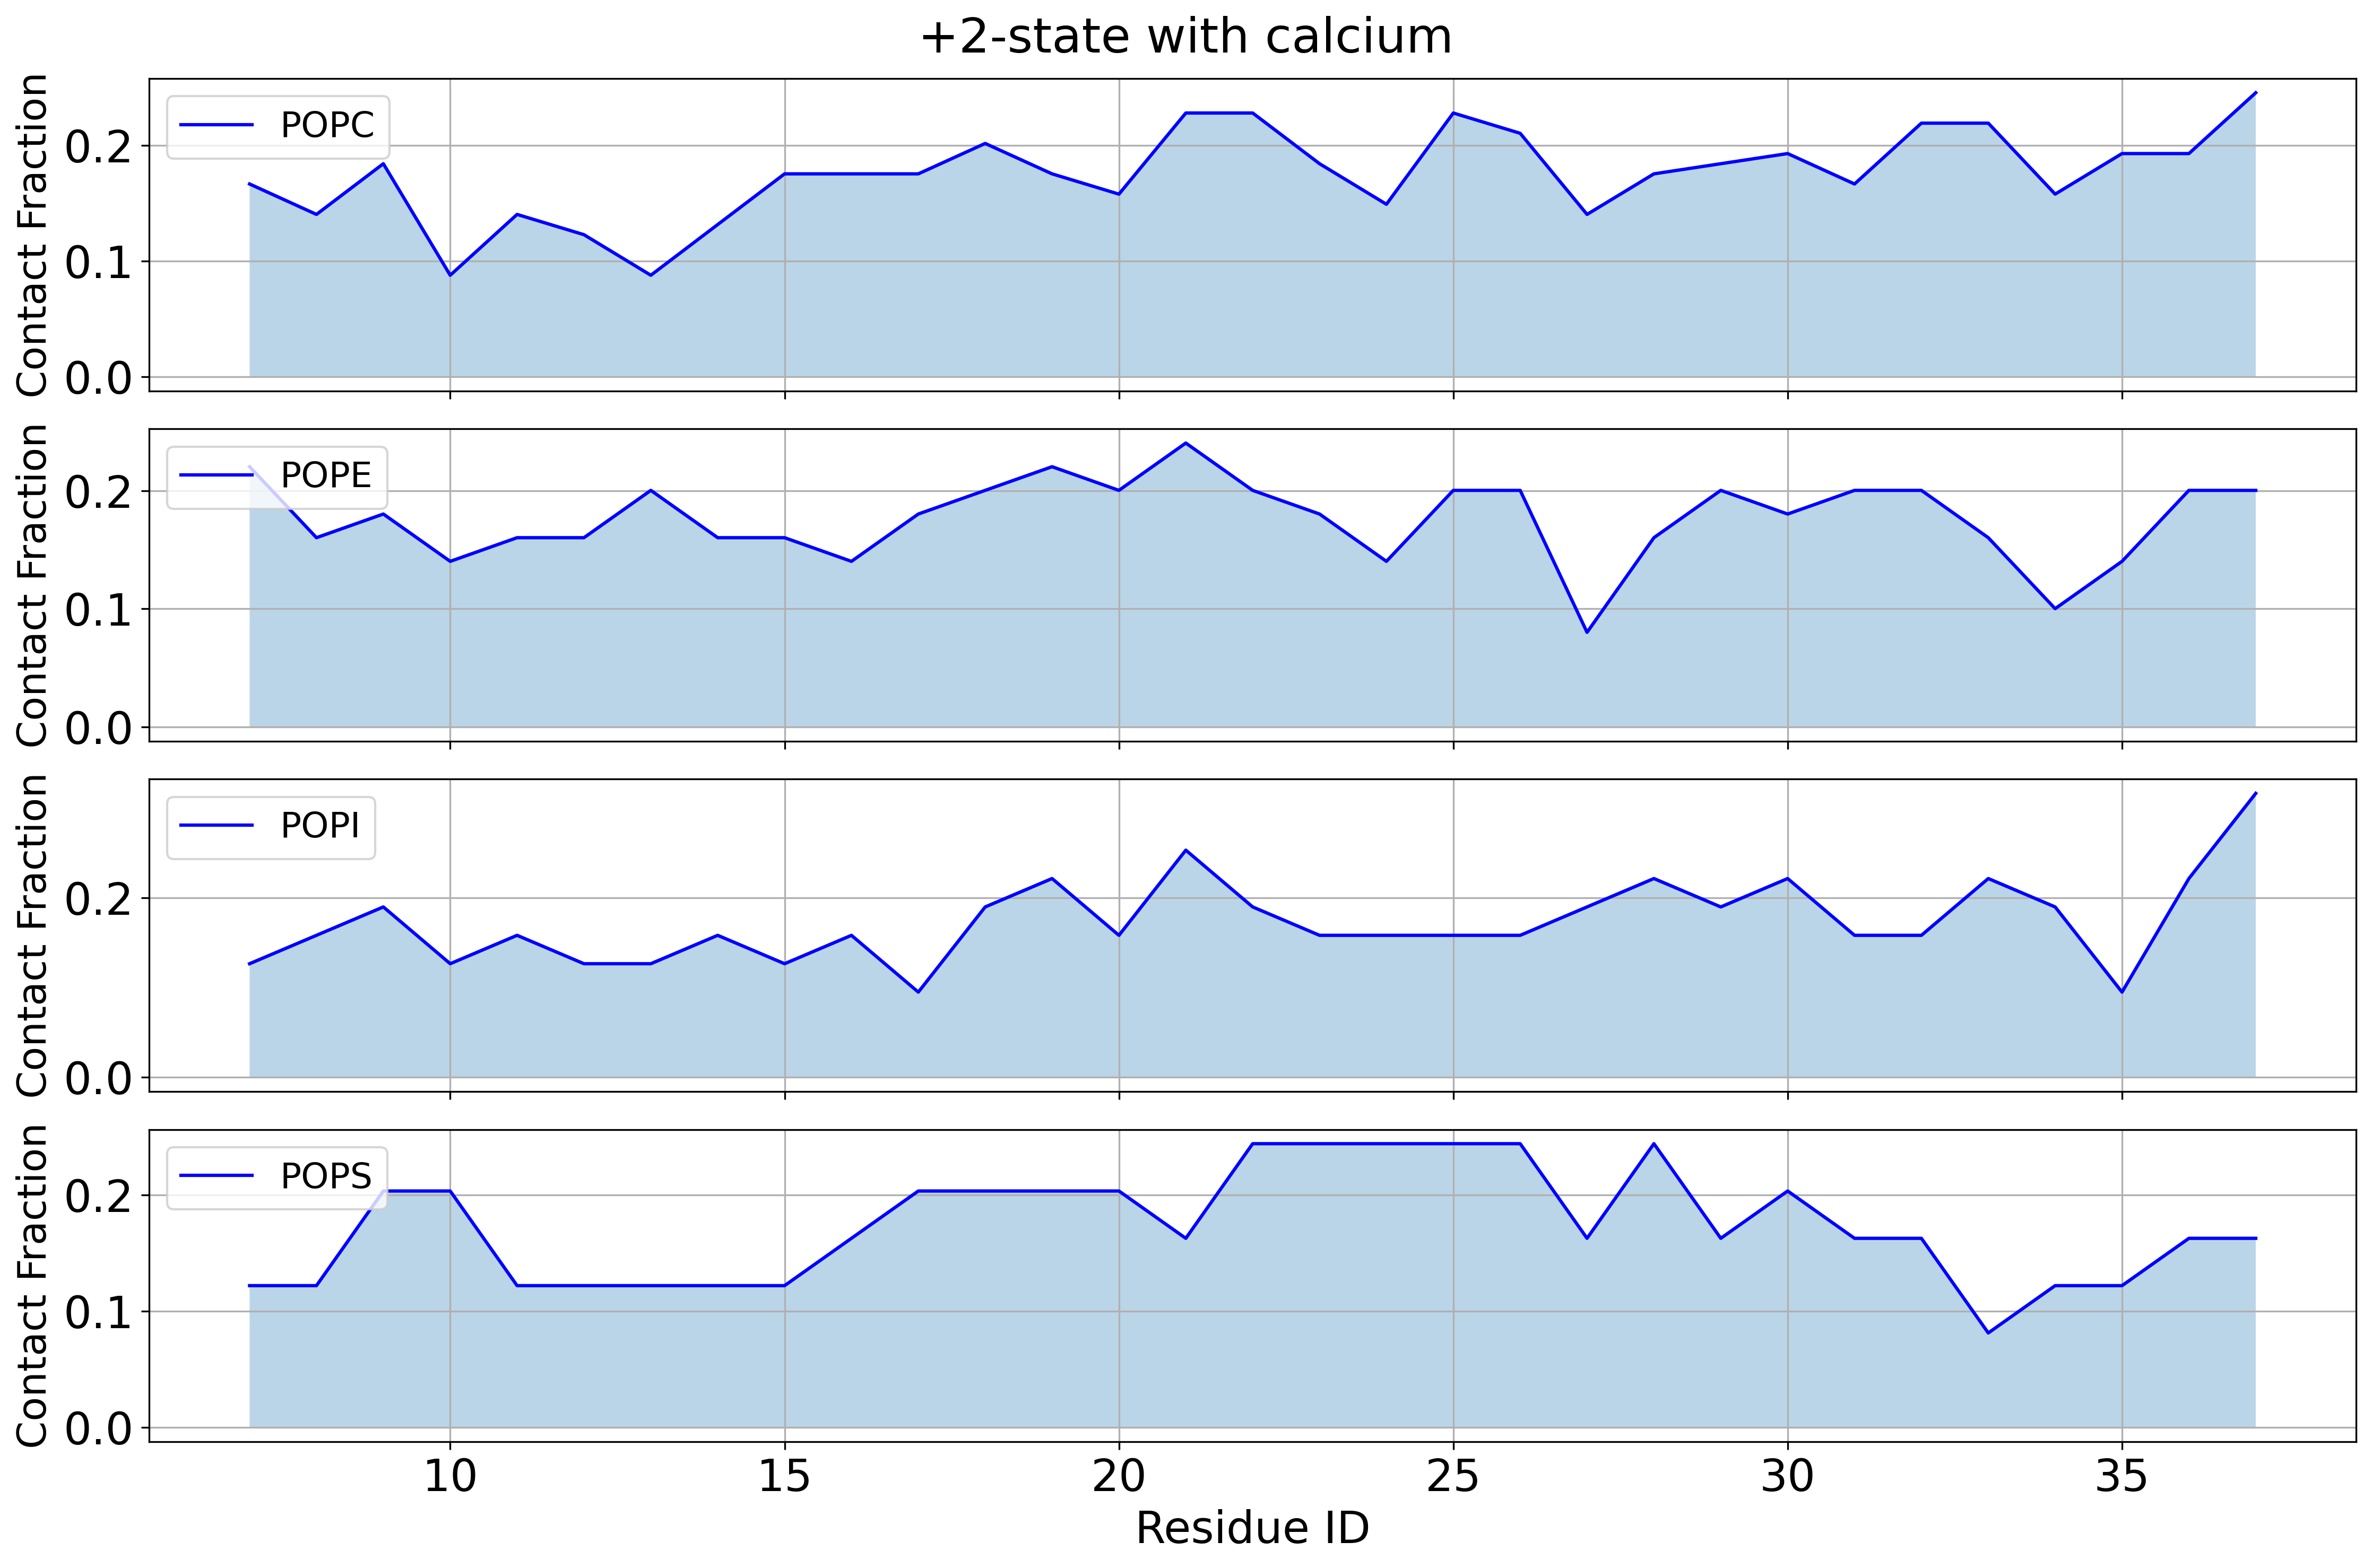

In [14]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing

topology = '+2-with-Ca.pdb'
u = mda.Universe(topology)

protein_ca_selection = 'protein and segid PROA'

lipids = ['POPC', 'POPE', 'POPI', 'POPS']
cutoff = 10.0

fig, axs = plt.subplots(4, 1, sharex=True, figsize=(15, 10), dpi=300)  # Create subplots

for idx, lipid in enumerate(lipids):
    residue_indices = []
    contact_fractions = []
    
    for residue in u.select_atoms(protein_ca_selection).residues:
        residue_indices.append(residue.resid-1)
        lipid_selection = u.select_atoms(f"resname {lipid} and around {cutoff} resid {residue.resid}")
        lipid_ids_within_cutoff = set(lipid_selection.resids)
        contact_fraction = len(lipid_ids_within_cutoff) / len(u.select_atoms(f"resname {lipid}").residues)
        contact_fractions.append(contact_fraction)

    normalized_contact_fractions = preprocessing.normalize([np.array(contact_fractions)])[0]
    
    axs[idx].plot(residue_indices, normalized_contact_fractions, color = "blue", label=lipid)
    axs[idx].fill_between(residue_indices, normalized_contact_fractions, alpha=0.3)
    axs[idx].set_ylabel('Contact Fraction',fontsize=18)
    axs[idx].legend(loc="upper left", fontsize=16)
    axs[idx].grid(True)
    axs[idx].tick_params(axis='both', which='major', labelsize=20)

axs[3].set_xlabel('Residue ID', fontsize=20)
plt.suptitle("+2-state with calcium",fontsize=22)
plt.tight_layout()
#plt.savefig('+2_with_calcium_contact_fraction.png',dpi=300,bbox_inches='tight')
plt.show()

ValueError: Found array with 0 feature(s) (shape=(1, 0)) while a minimum of 1 is required by the normalize function.

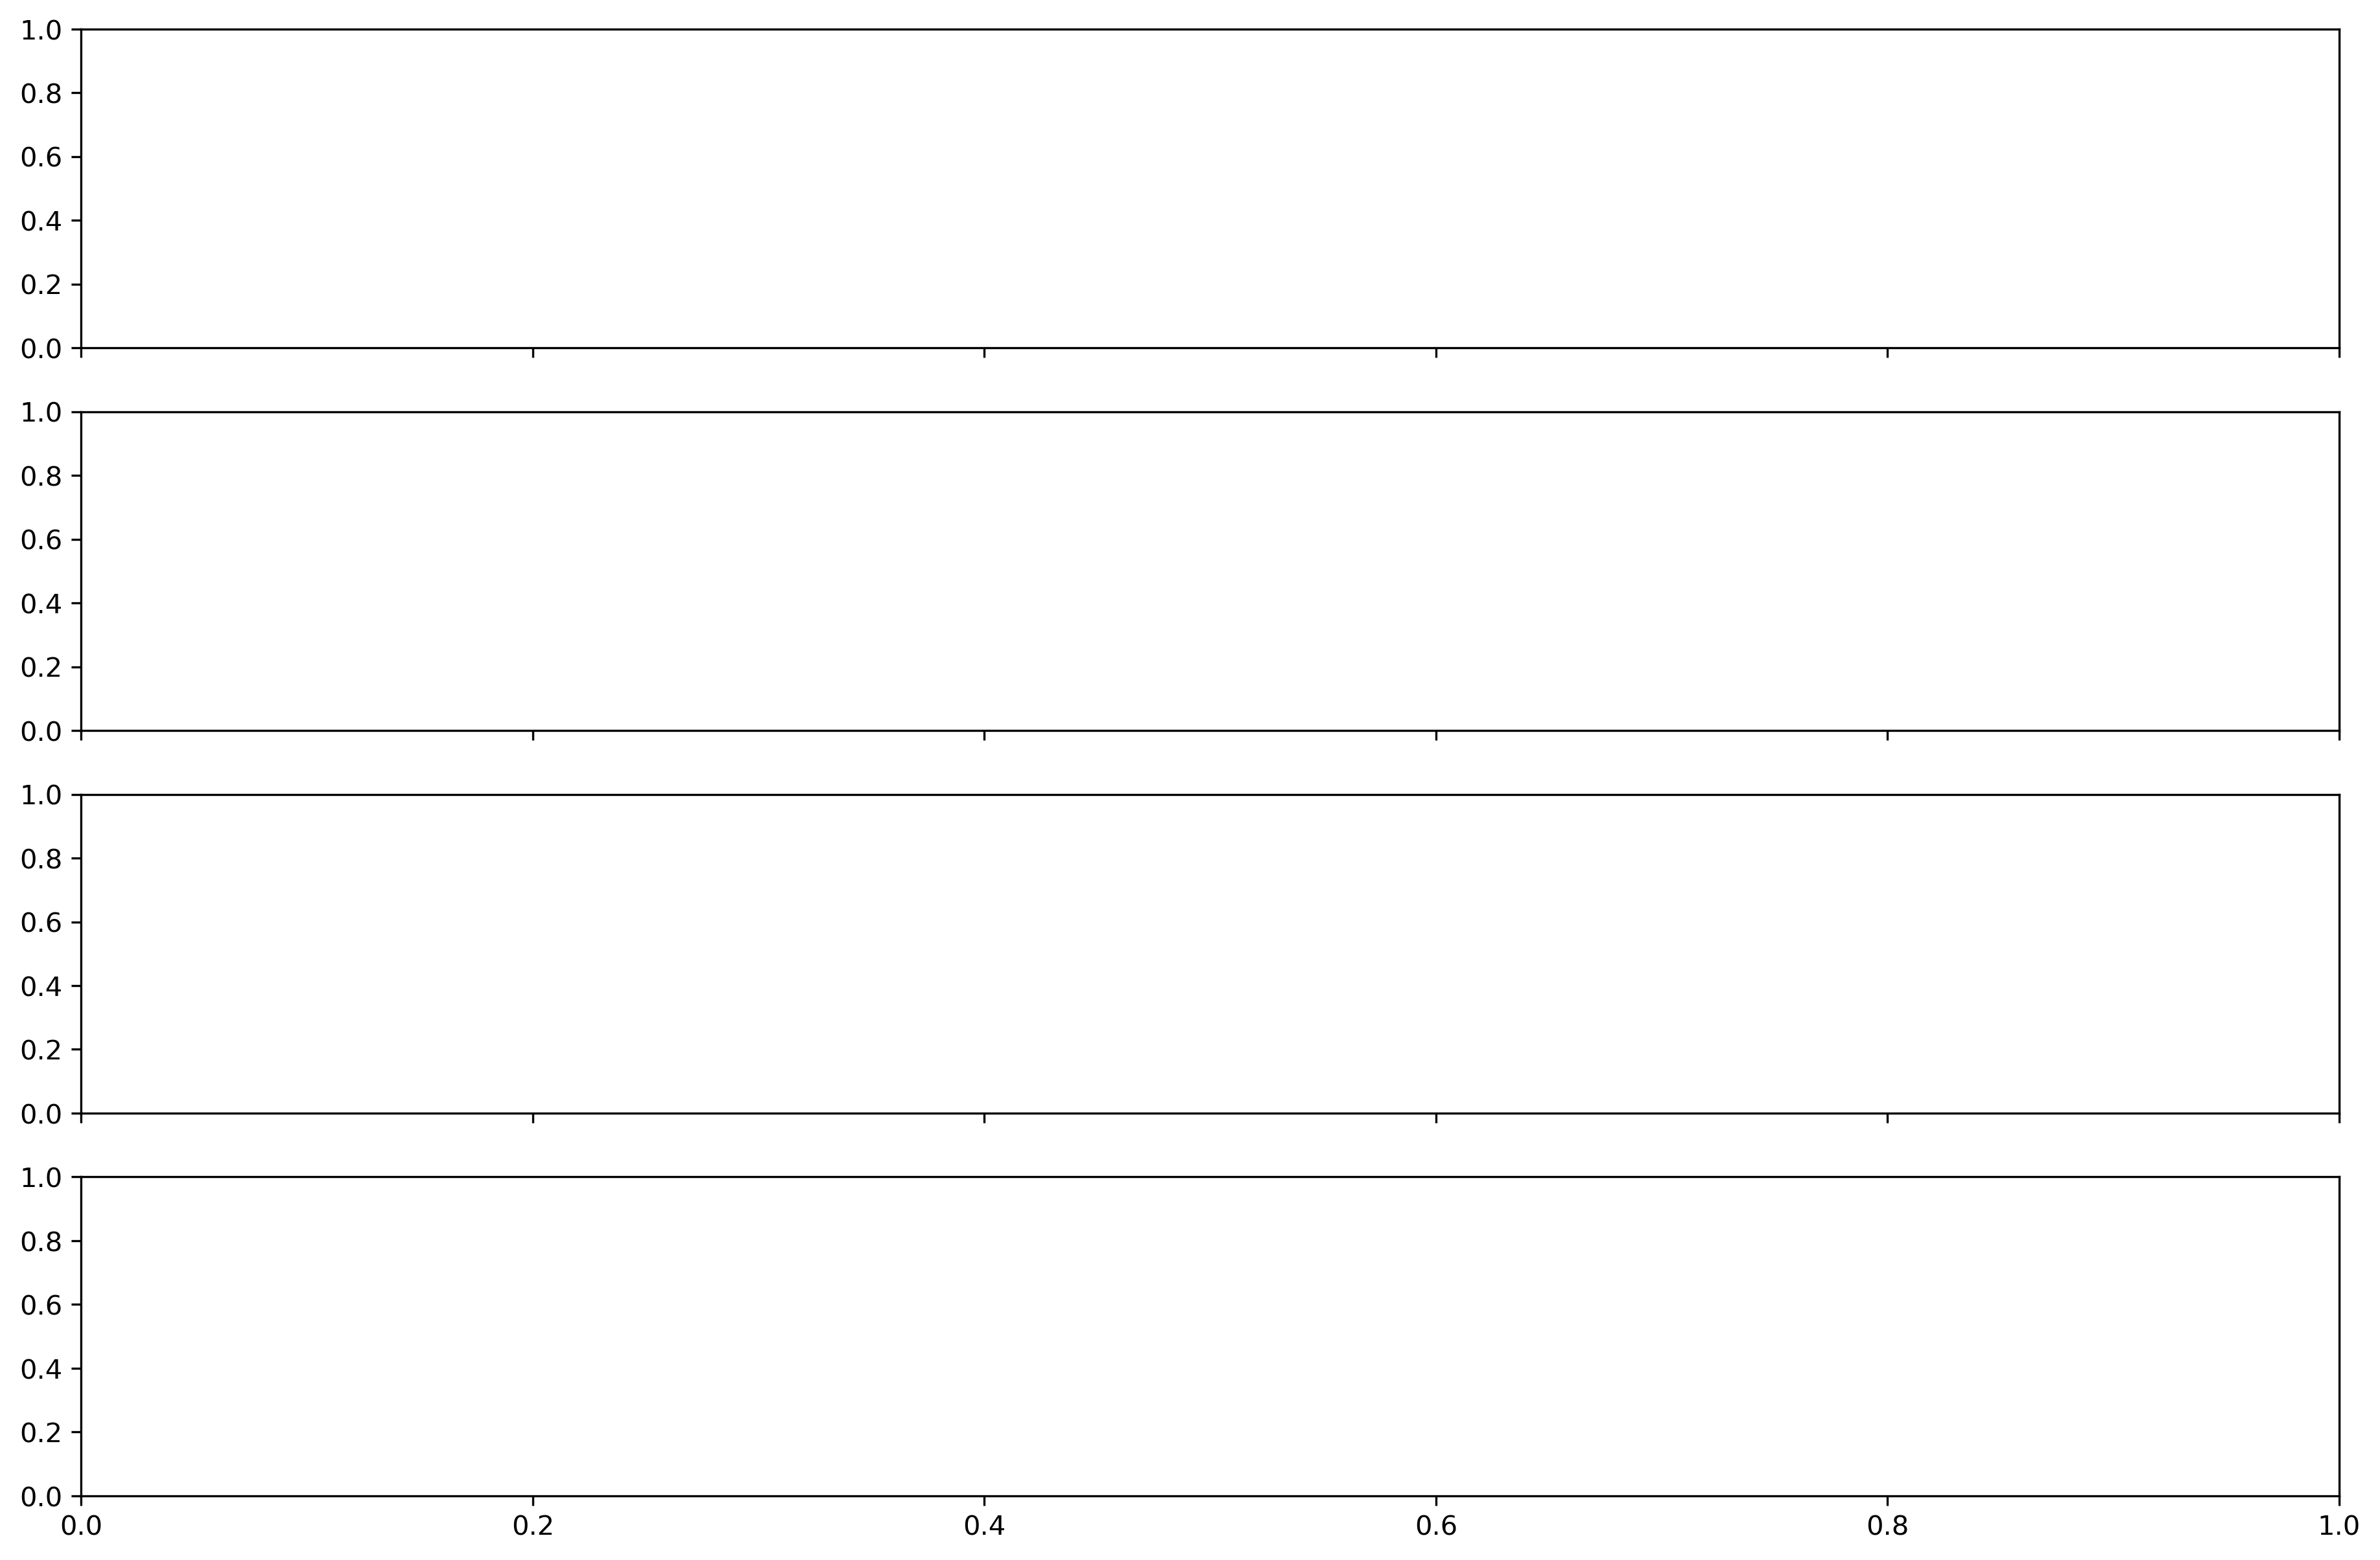

In [13]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing

topology = '+4-with-Ca.gro'
u = mda.Universe(topology)

protein_ca_selection = 'protein and segid PROA'

lipids = ['POPC', 'POPE', 'POPI', 'POPS']
cutoff = 10.0

fig, axs = plt.subplots(4, 1, sharex=True, figsize=(15, 10), dpi=300)  # Create subplots

for idx, lipid in enumerate(lipids):
    residue_indices = []
    contact_fractions = []
    
    for residue in u.select_atoms(protein_ca_selection).residues:
        residue_indices.append(residue.resid)
        lipid_selection = u.select_atoms(f"resname {lipid} and around {cutoff} resid {residue.resid}")
        lipid_ids_within_cutoff = set(lipid_selection.resids)
        contact_fraction = len(lipid_ids_within_cutoff) / len(u.select_atoms(f"resname {lipid}").residues)
        contact_fractions.append(contact_fraction)

    normalized_contact_fractions = preprocessing.normalize([np.array(contact_fractions)])[0]
    
    axs[idx].plot(residue_indices, normalized_contact_fractions, color = "blue", label=lipid)
    axs[idx].fill_between(residue_indices, normalized_contact_fractions, alpha=0.3)
    axs[idx].set_ylabel('Contact Fraction',fontsize=18)
    axs[idx].legend(loc="upper left", fontsize=16)
    axs[idx].grid(True)
    axs[idx].tick_params(axis='both', which='major', labelsize=20)

axs[3].set_xlabel('Residue ID', fontsize=20)
plt.suptitle("+4-state with calcium",fontsize=22)
plt.tight_layout()
#plt.savefig('+4_with_calcium_contact_fraction.png',dpi=300,bbox_inches='tight')
plt.show()

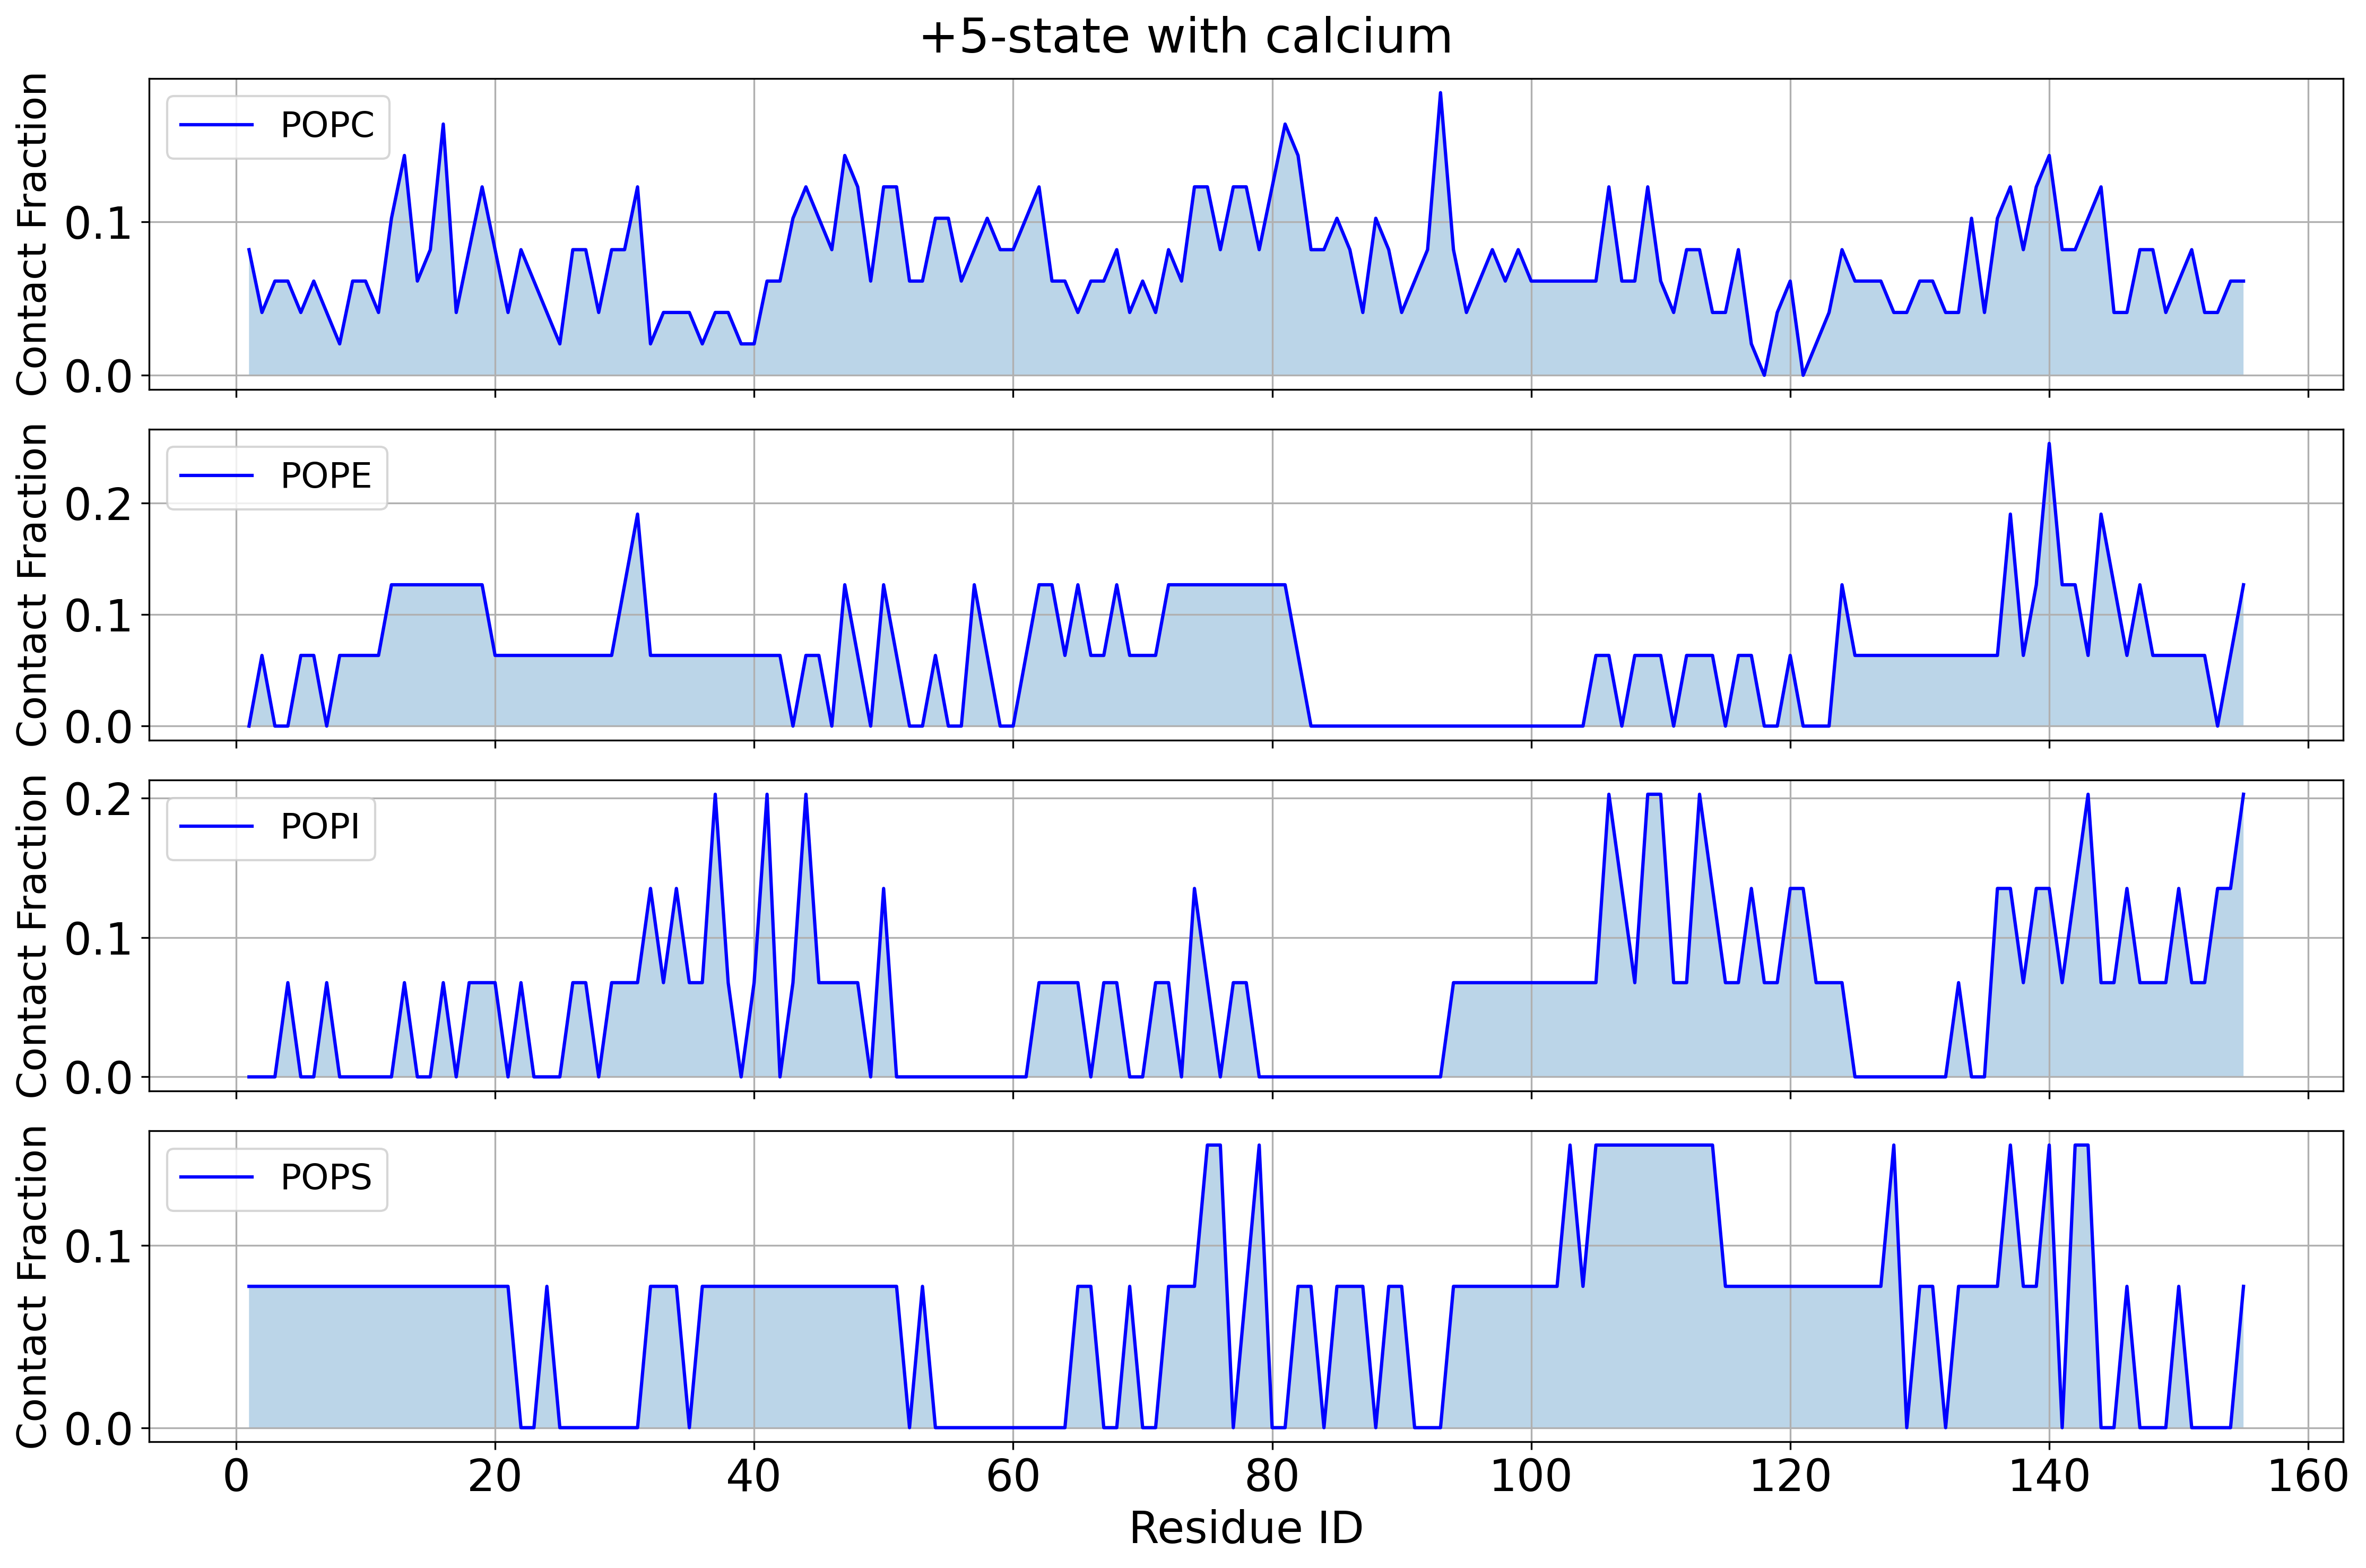

In [255]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing

topology = '+5-with-Ca.gro'
u = mda.Universe(topology)

protein_ca_selection = 'protein and name CA'

lipids = ['POPC', 'POPE', 'POPI', 'POPS']
cutoff = 10.0

fig, axs = plt.subplots(4, 1, sharex=True, figsize=(15, 10), dpi=300)  # Create subplots

for idx, lipid in enumerate(lipids):
    residue_indices = []
    contact_fractions = []
    
    for residue in u.select_atoms(protein_ca_selection).residues:
        residue_indices.append(residue.resid)
        lipid_selection = u.select_atoms(f"resname {lipid} and around {cutoff} resid {residue.resid}")
        lipid_ids_within_cutoff = set(lipid_selection.resids)
        contact_fraction = len(lipid_ids_within_cutoff) / len(u.select_atoms(f"resname {lipid}").residues)
        contact_fractions.append(contact_fraction)

    normalized_contact_fractions = preprocessing.normalize([np.array(contact_fractions)])[0]
    
    axs[idx].plot(residue_indices, normalized_contact_fractions, color = "blue", label=lipid)
    axs[idx].fill_between(residue_indices, normalized_contact_fractions, alpha=0.3)
    axs[idx].set_ylabel('Contact Fraction',fontsize=18)
    axs[idx].legend(loc="upper left", fontsize=16)
    axs[idx].grid(True)
    axs[idx].tick_params(axis='both', which='major', labelsize=20)

axs[3].set_xlabel('Residue ID', fontsize=20)
plt.suptitle("+5-state with calcium",fontsize=22)
plt.tight_layout()
plt.savefig('+5_with_calcium_contact_fraction.png',dpi=300,bbox_inches='tight')
plt.show()

In [7]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing

def plot_contact_fraction(topology_with_ca, topology_without_ca,suptitle_name,output_filename):
    lipids = ['POPC', 'POPE', 'POPI', 'POPS','CHL1']
    cutoff = 10.0

    fig, axs = plt.subplots(5, 1, sharex=True, figsize=(15, 20), dpi=300)

    colors = ['red', 'blue']

    for lipid in lipids:
        ax = axs[lipids.index(lipid)]
        
        for idx, topology_file in enumerate([topology_with_ca, topology_without_ca]):
            u = mda.Universe(topology_file, topology_file)
            protein_ca_selection = 'protein and segid PROA'
            
            residue_indices = []
            contact_fractions = []

            for residue in u.select_atoms(protein_ca_selection).residues:
                residue_indices.append(residue.resid-7)
                lipid_selection = u.select_atoms(f"resname {lipid} and around {cutoff} resid {residue.resid}")
                lipid_ids_within_cutoff = set(lipid_selection.resids)
                contact_fraction = len(lipid_ids_within_cutoff) 
                #/ len(u.select_atoms(f"resname {lipid}").residues)
                contact_fractions.append(contact_fraction)

            normalized_contact_fractions = preprocessing.normalize([np.array(contact_fractions)])[0]
            with_ca_label = f'With Ca$^{{2+}}$' if idx == 0 else f'Without Ca$^{{2+}}$'
            ax.plot(residue_indices, normalized_contact_fractions, color=colors[idx],label=with_ca_label)
            ax.fill_between(residue_indices, normalized_contact_fractions,alpha = 0.3, color=colors[idx])

            ax.set_ylabel('Contact Fraction',fontsize=20)
            ax.set_title(f'{lipid}',fontsize=16)  
            ax.legend(loc="upper left", fontsize=18)
            ax.grid(True)
            ax.tick_params(axis='both', which='major', labelsize=20)
    axs[-1].set_xlabel('Residue ID', fontsize=20)

    plt.tight_layout()
    plt.subplots_adjust(top=0.95)
    plt.suptitle(suptitle_name, fontsize=22, fontweight='bold')
    plt.savefig(output_filename,dpi=300,bbox_inches='tight')
    plt.show()
    print(residue_indices)

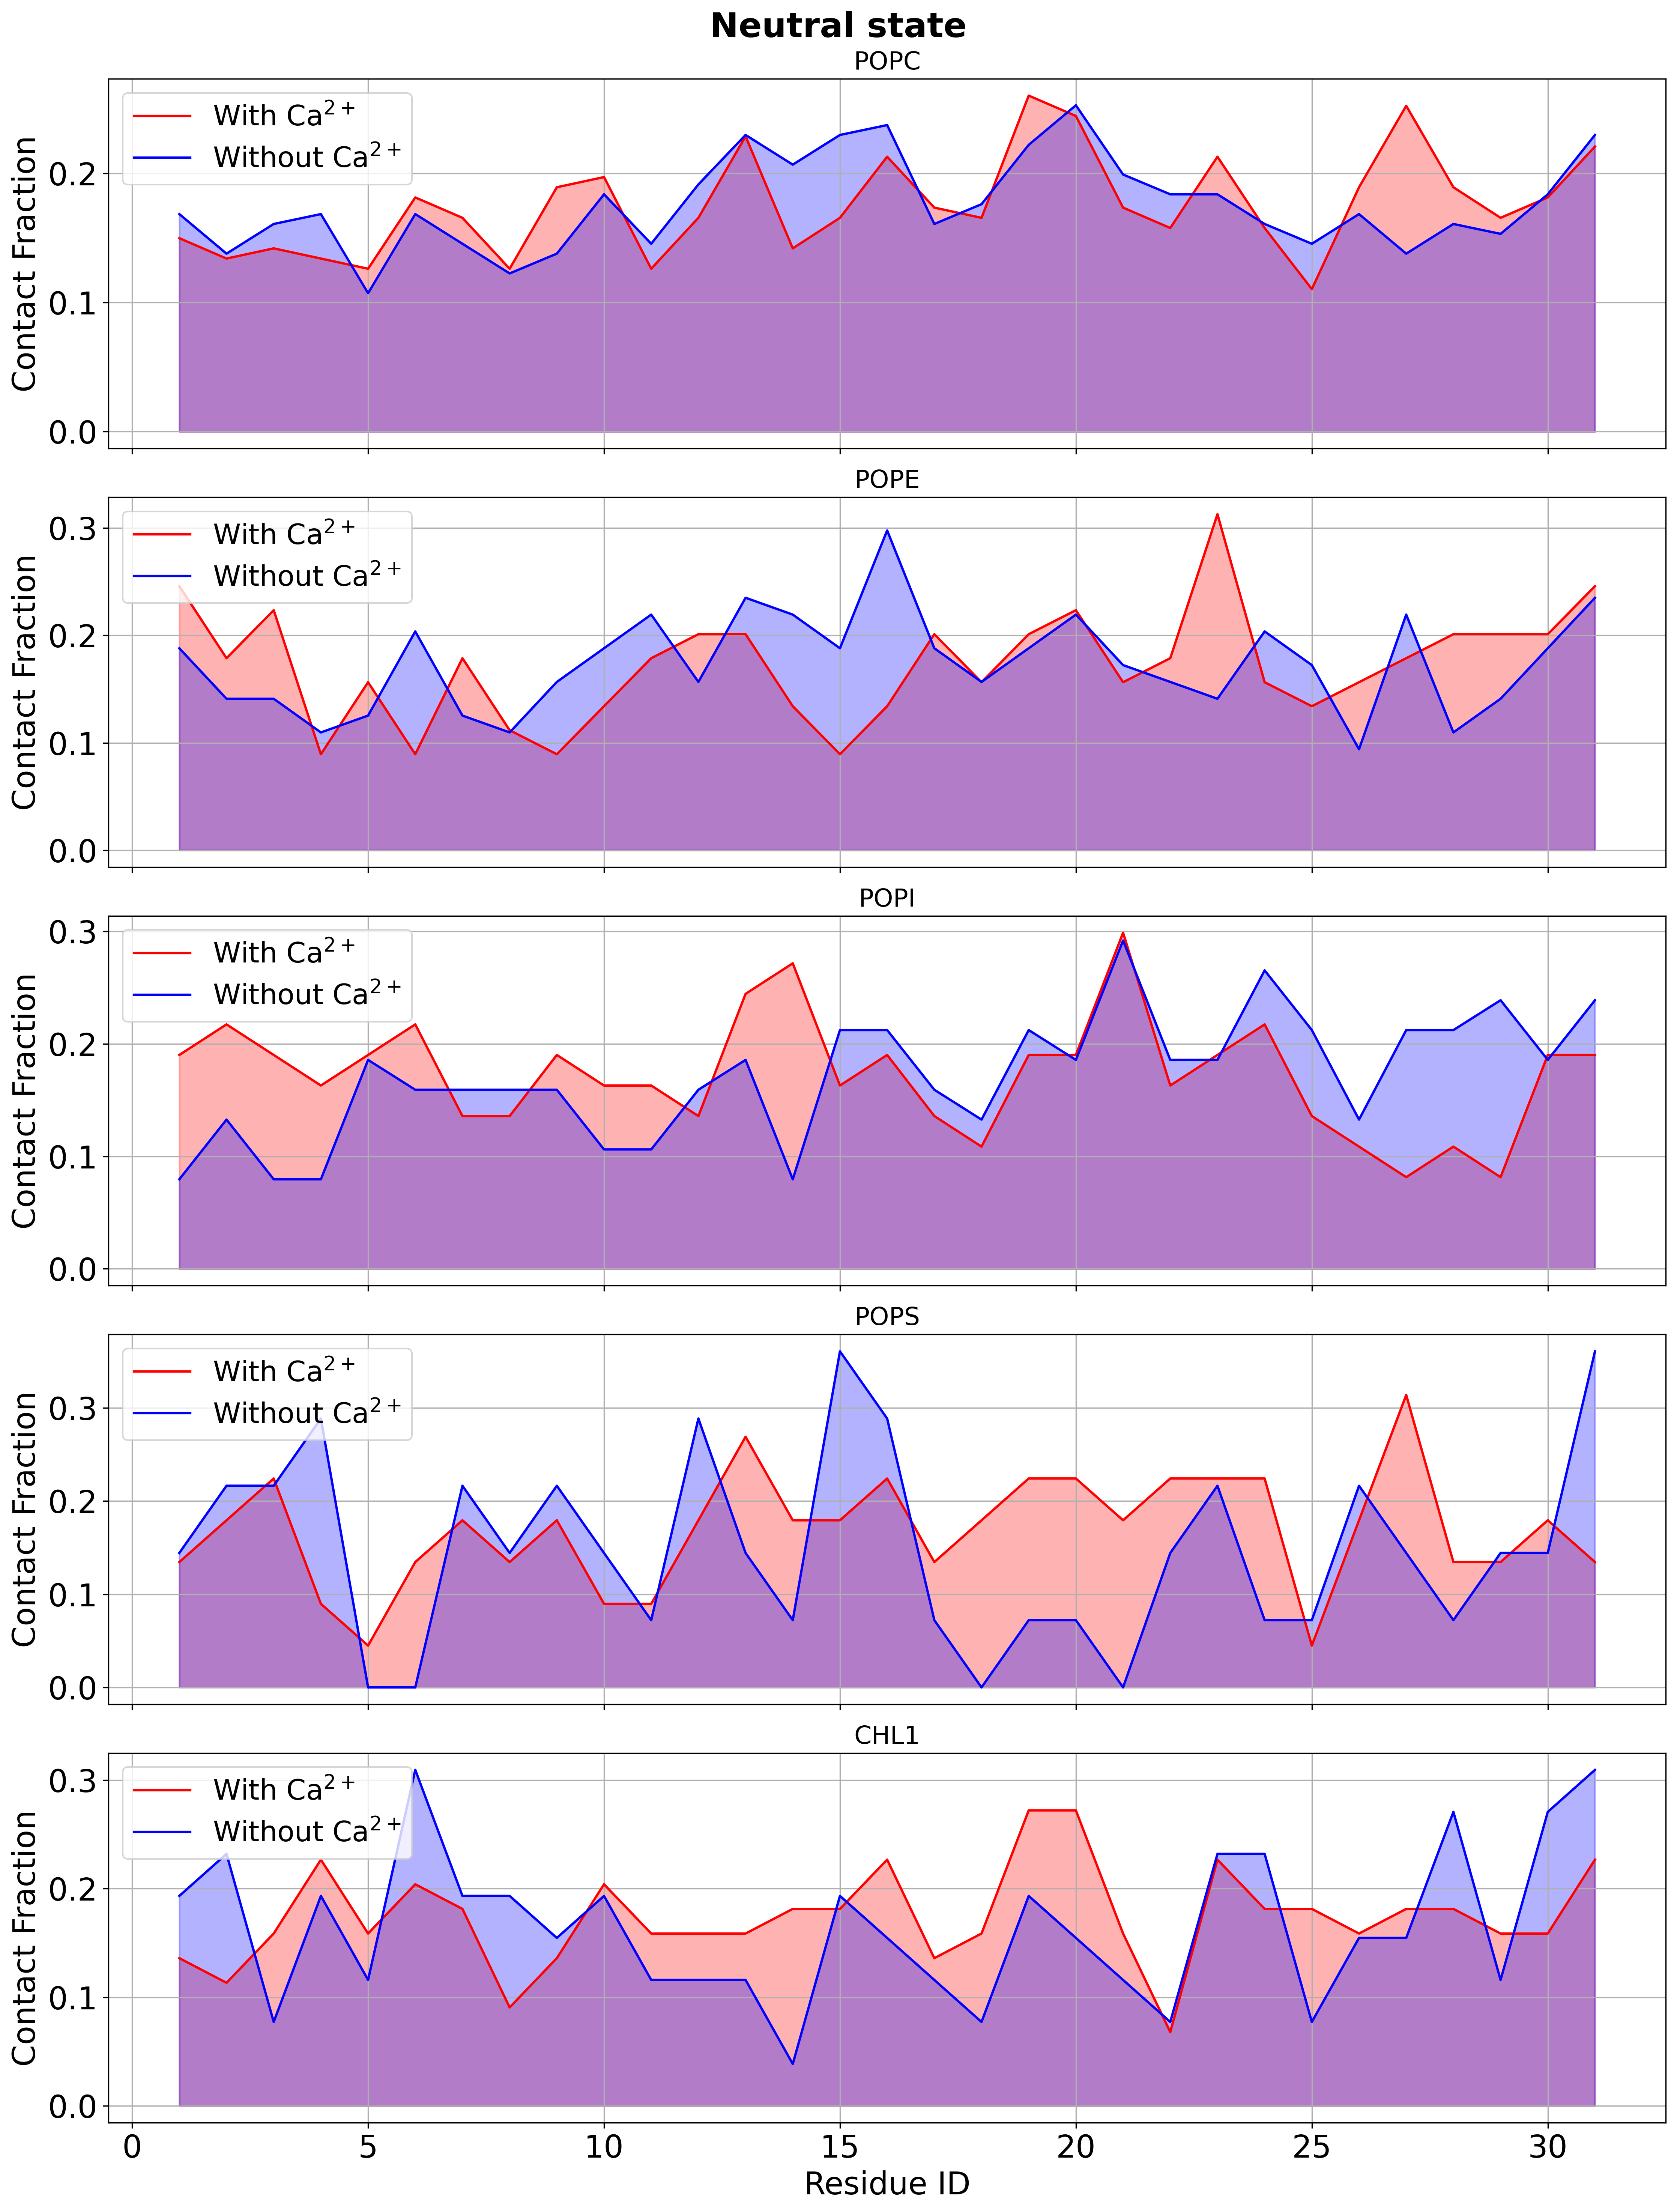

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]


In [8]:
topology_with_ca = 'Neutral-with-Ca.pdb'
topology_without_ca = 'Neutral-without-calcium.pdb'
plot_contact_fraction(topology_with_ca, topology_without_ca, "Neutral state", "Neutral_state_contact_fraction.png")

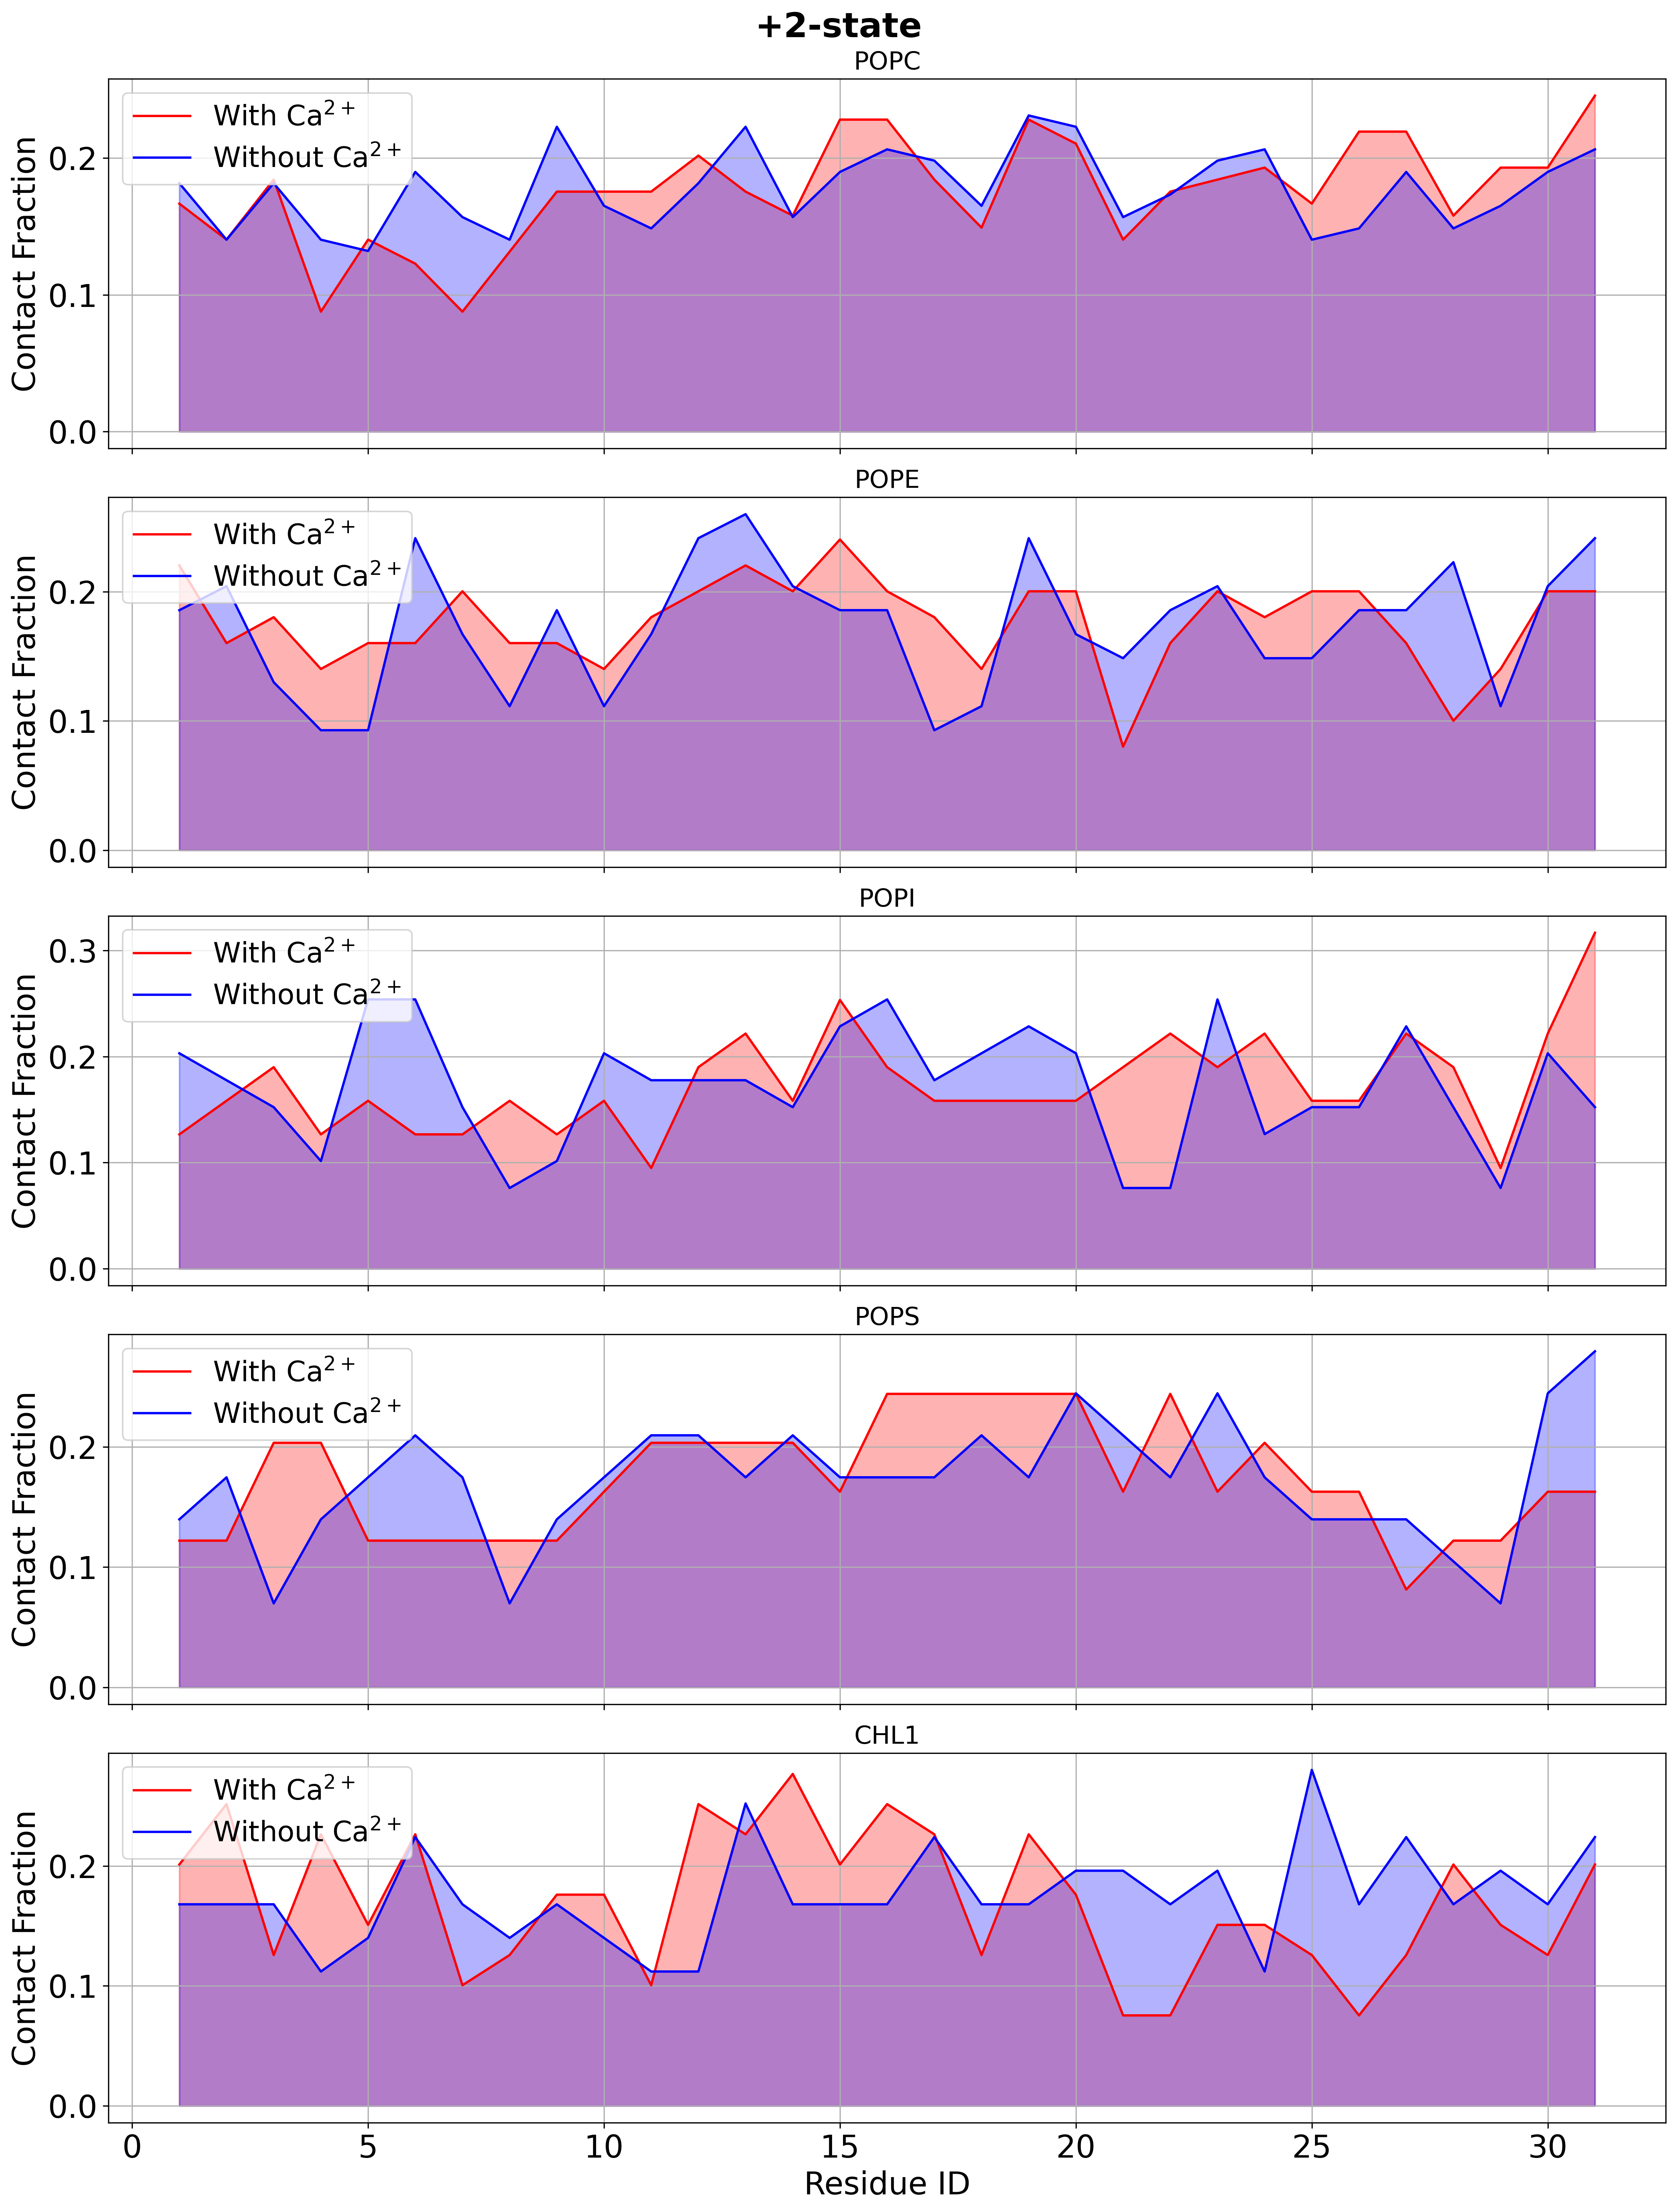

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]


NameError: name 'normalized_contact_fractions' is not defined

In [9]:
topology_with_ca = '+2-with-Ca.pdb'
topology_without_ca = '+2-without-Ca.pdb'
plot_contact_fraction(topology_with_ca, topology_without_ca, "+2-state", "+2_state_contact_fraction.png")
print(normalized_contact_fractions)

In [ ]:
topology_with_ca = '+4-with-Ca.pdb'
topology_without_ca = '+4-without-Ca.pdb'
plot_contact_fraction(topology_with_ca, topology_without_ca, "+4-state", "+4_state_contact_fraction.png")

In [ ]:
topology_with_ca = '+5-with-Ca.pdb'
topology_without_ca = '+5-without-Ca.pdb'
plot_contact_fraction(topology_with_ca, topology_without_ca, "+5-state", "+5_state_contact_fraction.png")

In [ ]:
plt.fill_between()